#  Stance Classification

**Dataset:** SemEval 2016 Task 6  1,249 test documents · 5 targets  
*(Atheism, Climate Change, Feminist Movement, Hillary Clinton, Legalization of Abortion)*  
**Task:** 3-class stance classification (FAVOR / AGAINST / NONE)  
**Primary metric:** Macro-F1 (unweighted mean across all three classes)  
**Shot counts analysed:** 0 (= `task_definition`), 3, 6, 9, 12

---

### Research Questions
1. How does stance classification performance change as the number of in-context examples increases?
2. Do the gains from additional shots saturate, and if so, at what point for each model?
3. Do SLMs and LLMs behave differently as shot count increases?
4. Which stance classes benefit most from additional shots?
5. What proportion of test examples change prediction as shot count increases?
6. Which examples are corrected by more shots, and which are harmed by more shots?
7. Which examples remain unstable across shot counts and across models?
8. Are there examples that are difficult mainly for SLMs but not for LLMs?

---
## 1 · Setup

In [82]:
# ── Imports (reused from stance_results_team_analysis.ipynb) ──────────────
from pathlib import Path
import re
from itertools import combinations
import warnings
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from scipy import stats as scipy_stats
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_recall_fscore_support,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', context='talk', font_scale=1.0)
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.alpha': 0.35,
})
pd.set_option('display.max_columns', 200)
pd.set_option('display.float_format', '{:.3f}'.format)

In [83]:
# ── Paths & label constants ───────────────────────────────────────────────
RUNS_ROOT = Path('../data_out/stance/semeval_results/')
LABELS    = ['FAVOR', 'AGAINST', 'NONE']
RNG       = np.random.default_rng(42)

# ICL prompts: 0-shot is 'task_definition'; few-shot are named few_shot_N
# Note: 'task_definition' is treated as 0-shot throughout this notebook.
ICL_PROMPTS     = ['task_definition', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'few_shot_12', 'few_shot_15']
ICL_SHOT_COUNTS = [0, 3, 6, 9, 12, 15]
SHOT_MAP        = dict(zip(ICL_PROMPTS, ICL_SHOT_COUNTS))  # prompt -> n_shots

SEMANTIC_ICL_PROMPTS     = ['semantic_icl_3', 'semantic_icl_6', 'semantic_icl_9', 'semantic_icl_12', 'semantic_icl_15']
SEMANTIC_ICL_SHOT_COUNTS = [3, 6, 9, 12, 15]
SEMANTIC_SHOT_MAP        = dict(zip(SEMANTIC_ICL_PROMPTS, SEMANTIC_ICL_SHOT_COUNTS))

PROMPT_LABELS = {   # human-readable names for axis labels
    'task_definition':  '0-shot',
    'few_shot_3':       '3-shot (random)',
    'few_shot_6':       '6-shot (random)',
    'few_shot_9':       '9-shot (random)',
    'few_shot_12':      '12-shot (random)',
    'few_shot_15':      '15-shot (random)',
    'semantic_icl_3':   '3-shot (semantic)',
    'semantic_icl_6':   '6-shot (semantic)',
    'semantic_icl_9':   '9-shot (semantic)',
    'semantic_icl_12':  '12-shot (semantic)',
    'semantic_icl_15':  '15-shot (semantic)',
}

# ── Model metadata (reused from stance_results_team_analysis.ipynb) ───────
MODEL_SIZES = {
    'Qwen3-1.7B':                    1.7,
    'phi-4-mini-instruct':           3.8,
    'Nemotron-Mini-4B-Instruct':     4.0,
    'Qwen3-4B':                      4.0,
    'Qwen3-4B-Instruct-2507':        4.0,
    'Llama-3.1-8B-Instruct':         8.0,
    'DeepSeek-R1-Distill-Llama-8B':  8.0,
    'Qwen3-8B':                      8.0,
    'DeepSeek-R1-Distill-Qwen-14B': 14.0,
    'Qwen3-14B':                    14.0,
    'phi-4':                        14.0,
    'DeepSeek-R1-Distill-Qwen-32B': 32.0,
    'Qwen3-32B':                    32.0,
    # gpt-5-mini, gpt-5.2: closed-source, size undisclosed
}

MODEL_FAMILY = {
    'Qwen3-1.7B':                   'Qwen3',
    'Qwen3-4B':                     'Qwen3',
    'Qwen3-4B-Instruct-2507':       'Qwen3',
    'Qwen3-8B':                     'Qwen3',
    'Qwen3-14B':                    'Qwen3',
    'Qwen3-32B':                    'Qwen3',
    'Llama-3.1-8B-Instruct':        'Llama',
    'DeepSeek-R1-Distill-Llama-8B': 'DeepSeek-R1',
    'DeepSeek-R1-Distill-Qwen-14B': 'DeepSeek-R1',
    'DeepSeek-R1-Distill-Qwen-32B': 'DeepSeek-R1',
    'Nemotron-Mini-4B-Instruct':    'Nemotron',
    'phi-4-mini-instruct':          'Phi',
    'phi-4':                        'Phi',
    'gpt-5-mini':                   'GPT-5',
    'gpt-5.2':                      'GPT-5',
    'claude-haiku-4-5-20251001':    'Claude',
}

_CLOSED_SOURCE_RANK = {
    'gpt-5-mini':                0,
    'gpt-5.2':                   1,
    'claude-haiku-4-5-20251001': 2,
}

FAMILY_COLORS = {
    'Qwen3':       '#4C78A8',
    'DeepSeek-R1': '#F58518',
    'Llama':       '#72B7B2',
    'Nemotron':    '#76B900',
    'Phi':         '#E45756',
    'GPT-5':       '#54A24B',
    'Claude':      '#D4682A',
    'Other':       '#B279A2',
}

# SLM threshold: < 14 B parameters (closed-source counted as LLM)
SLM_THRESHOLD_B = 14.0

SEMEVAL_BASELINE = 0.69
F1_USABLE        = 0.55

In [84]:
# ── Helper functions (reused from stance_results_team_analysis.ipynb) ─────

def parse_run_folder(name: str):
    """Extract (model, prompt) from a results folder name."""
    m = re.match(r'.*semeval2016_task6_testdata_gold_(.+)_equal_(.+)$', name)
    return (m.group(1), m.group(2)) if m else None

def norm_label(x):
    """Normalise a raw predicted label to FAVOR / AGAINST / NONE (or NaN)."""
    if pd.isna(x): return np.nan
    s = str(x).strip().upper()
    if 'FAVOR'   in s: return 'FAVOR'
    if 'AGAINST' in s: return 'AGAINST'
    if s in {'NONE', 'NEITHER', 'NEUTRAL'}: return 'NONE'
    return s

def model_sort_key(model):
    """Sort key: size (desc) → closed-source rank → family → name."""
    size = MODEL_SIZES.get(model, 999)
    cs_rank = _CLOSED_SOURCE_RANK.get(model, 99) if model not in MODEL_SIZES else 99
    return (-size, cs_rank, MODEL_FAMILY.get(model, 'zzz'), model)

def family_color(model):
    return FAMILY_COLORS.get(MODEL_FAMILY.get(model, 'Other'), '#888888')

def build_model_colors(models):
    """Return {model: hex_color} with distinct lightness shades per family."""
    import colorsys
    from collections import defaultdict

    family_members = defaultdict(list)
    for m in models:
        family_members[MODEL_FAMILY.get(m, 'Other')].append(m)

    result = {}
    for fam, members in family_members.items():
        base = FAMILY_COLORS.get(fam, '#888888')
        h, l, s = colorsys.rgb_to_hls(*mcolors.to_rgb(base))
        n = len(members)
        if n == 1:
            result[members[0]] = base
        else:
            lums = np.linspace(0.28, 0.62, n)
            for m, lum in zip(members, lums):
                result[m] = mcolors.to_hex(colorsys.hls_to_rgb(h, lum, s))
    return result

def is_slm(model):
    """True if model has a known size below SLM_THRESHOLD_B."""
    size = MODEL_SIZES.get(model)
    return size is not None and size < SLM_THRESHOLD_B

def is_llm(model):
    """True if model is >= SLM_THRESHOLD_B or closed-source."""
    size = MODEL_SIZES.get(model)
    return size is None or size >= SLM_THRESHOLD_B

In [85]:
# ── Load results (ICL prompts only) ──────────────────────────────────────
# Adapted from stance_results_team_analysis.ipynb cell 4.
# The key change: we filter to ICL_PROMPTS only, and include 'content' for
# qualitative inspection in Section 8.

run_files = sorted(RUNS_ROOT.glob('*/document_assignments.csv'))
if not run_files:
    raise FileNotFoundError(f'No run files found under {RUNS_ROOT}')

system_frames = {}   # key: '{model} | {prompt}' → DataFrame
meta_rows     = []

for fp in run_files:
    parsed = parse_run_folder(fp.parent.name)
    if parsed is None:
        continue
    model, prompt = parsed

    # ── ICL filter: only keep the six ICL prompt conditions ───────────────
    if prompt not in ICL_PROMPTS:
        continue

    df = pd.read_csv(fp)
    needed = {'doc_id', 'original_stance', 'predicted_stance'}
    if needed - set(df.columns):
        continue

    cols = ['doc_id', 'original_stance', 'predicted_stance']
    if 'query'   in df.columns: cols.append('query')
    if 'content' in df.columns: cols.append('content')  # for qualitative section

    df = df[cols].copy()
    df['doc_id'] = df['doc_id'].astype(str)
    df['gold']   = df['original_stance'].map(norm_label)
    df['pred']   = df['predicted_stance'].map(norm_label)
    df['n_shots'] = SHOT_MAP[prompt]

    n_total     = len(df)
    n_parseable = df['pred'].isin(LABELS).sum()
    parse_fail  = 1.0 - n_parseable / n_total

    df = df[df['gold'].isin(LABELS) & df['pred'].isin(LABELS)].copy()

    system = f'{model} | {prompt}'
    system_frames[system] = df
    meta_rows.append({
        'system':     system,
        'model':      model,
        'prompt':     prompt,
        'n_shots':    SHOT_MAP[prompt],
        'family':     MODEL_FAMILY.get(model, 'Other'),
        'size_B':     MODEL_SIZES.get(model),
        'tier':       'SLM' if is_slm(model) else 'LLM',
        'parse_fail': round(parse_fail * 100, 2),
        'n_total':    n_total,
        'n_eval':     len(df),
    })

meta_df = (
    pd.DataFrame(meta_rows)
    .sort_values('n_eval', ascending=False)   # largest run wins on duplicate
    .drop_duplicates(subset=['system'])
    .sort_values(['model', 'n_shots'])
    .reset_index(drop=True)
)
print(f'Systems loaded : {len(system_frames)}')
print(f'Models         : {meta_df["model"].nunique()}')
print(f'Shot counts    : {sorted(meta_df["n_shots"].unique())}')
print()
print('Models with complete 0→15 coverage:')
counts = meta_df.groupby('model')['n_shots'].nunique()
print(counts[counts == 6].index.tolist())

Systems loaded : 84
Models         : 14
Shot counts    : [0, 3, 6, 9, 12, 15]

Models with complete 0→15 coverage:
['DeepSeek-R1-Distill-Llama-8B', 'DeepSeek-R1-Distill-Qwen-14B', 'Llama-3.1-8B-Instruct', 'Nemotron-Mini-4B-Instruct', 'Qwen3-1.7B', 'Qwen3-14B', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'Qwen3-8B', 'claude-haiku-4-5-20251001', 'gpt-5-mini', 'gpt-5.2', 'phi-4', 'phi-4-mini-instruct']


In [86]:
# ── Compute metrics for all (model, prompt) combinations ─────────────────

metric_rows = []
for _, m in meta_df.iterrows():
    d  = system_frames[m['system']]
    yt = d['gold'].values
    yp = d['pred'].values
    p, r, f, sup = precision_recall_fscore_support(yt, yp, labels=LABELS, zero_division=0)
    metric_rows.append({
        **m.to_dict(),
        'macro_f1':       f1_score(yt, yp, labels=LABELS, average='macro', zero_division=0),
        'accuracy':       accuracy_score(yt, yp),
        'p_FAVOR':   p[0], 'r_FAVOR':   r[0], 'f1_FAVOR':   f[0],
        'p_AGAINST': p[1], 'r_AGAINST': r[1], 'f1_AGAINST': f[1],
        'p_NONE':    p[2], 'r_NONE':    r[2], 'f1_NONE':    f[2],
        'support_FAVOR': sup[0], 'support_AGAINST': sup[1], 'support_NONE': sup[2],
    })

metrics = pd.DataFrame(metric_rows)
metrics['size_label'] = metrics['size_B'].apply(
    lambda x: f'{x:g}B' if pd.notna(x) else 'closed'
)

# ── Quick sanity table ────────────────────────────────────────────────────
overview = (
    metrics.groupby(['model', 'tier', 'size_B', 'size_label'], dropna=False)
    .agg(
        best_macro_f1 = ('macro_f1', 'max'),
        mean_macro_f1 = ('macro_f1', 'mean'),
        n_shots_tested = ('n_shots', 'nunique'),
    )
    .reset_index()
    .sort_values('size_B', ascending=False, na_position='first')
)
display(overview)

,model,tier,size_B,size_label,best_macro_f1,mean_macro_f1,n_shots_tested
9,claude-haiku-4-5-20251001,LLM,NaN,closed,0.765,0.748,6
10,gpt-5-mini,LLM,NaN,closed,0.756,0.747,6
11,gpt-5.2,LLM,NaN,closed,0.758,0.746,6
1,DeepSeek-R1-Distill-Qwen-14B,LLM,14.000,14B,0.655,0.634,6
5,Qwen3-14B,LLM,14.000,14B,0.668,0.637,6
12,phi-4,LLM,14.000,14B,0.702,0.683,6
0,DeepSeek-R1-Distill-Llama-8B,SLM,8.000,8B,0.561,0.549,6
2,Llama-3.1-8B-Instruct,SLM,8.000,8B,0.582,0.555,6
8,Qwen3-8B,SLM,8.000,8B,0.696,0.662,6
3,Nemotron-Mini-4B-Instruct,SLM,4.000,4B,0.652,0.580,6


---
## 2 · Performance vs Shot Count

**RQ1:** How does stance classification performance change as the number of in-context examples increases?

We plot macro-F1 vs shot count (0, 3, 6, 9, 12) for every model, then provide summary tables of per-class precision / recall / F1.

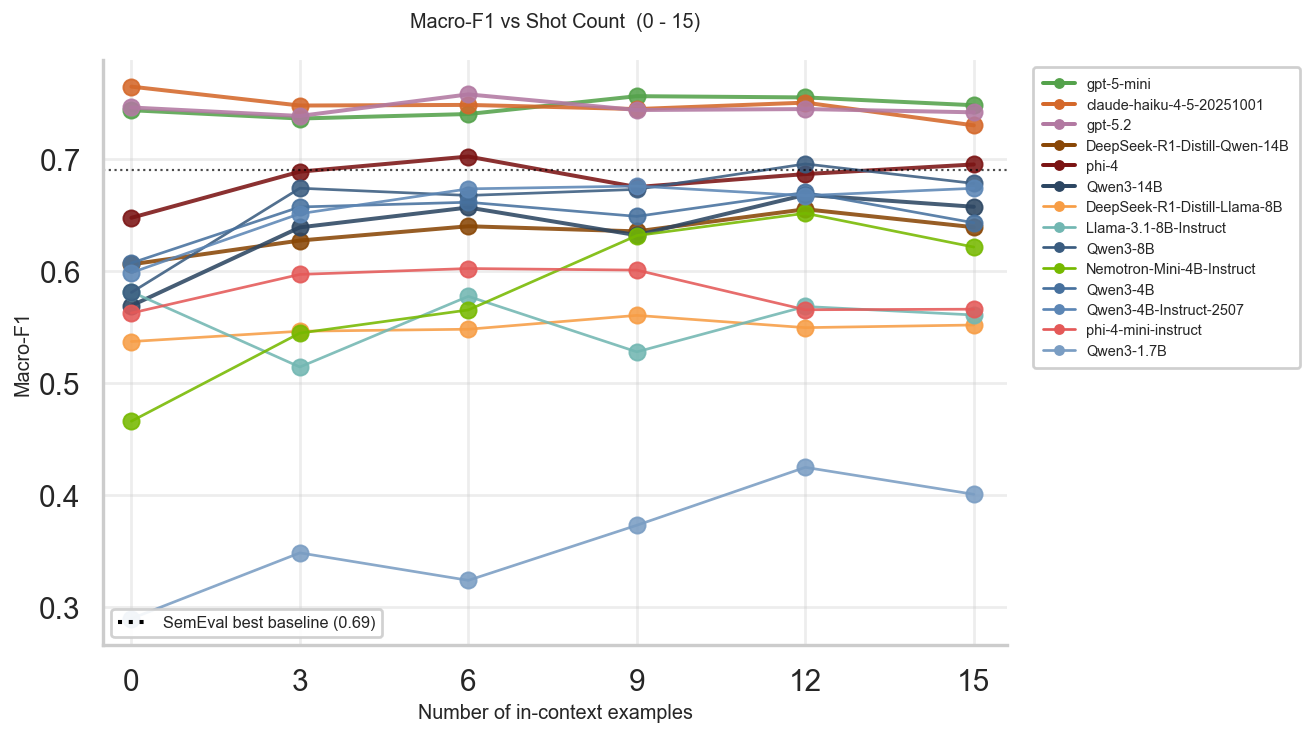

In [87]:
# ── Line chart: macro-F1 vs shot count (all models) ──────────────────────
# Adapted from stance_results_team_analysis.ipynb cell 12.

model_order = sorted(metrics['model'].unique(), key=model_sort_key)
model_colors = build_model_colors(model_order)

fig, ax = plt.subplots(figsize=(11, 6))

for model in model_order:
    sub   = metrics[metrics['model'] == model].sort_values('n_shots')
    color = model_colors.get(model, '#888888')
    size  = MODEL_SIZES.get(model)
    lw    = 2.2 if (size and size >= 14) or size is None else 1.5
    ls    = '-' if is_slm(model) else '-'
    ax.plot(sub['n_shots'], sub['macro_f1'], marker='o', color=color,
            linewidth=lw, linestyle=ls, alpha=0.88)

ax.axhline(SEMEVAL_BASELINE, color='#000',    linewidth=1.2, linestyle=':',  alpha=0.7)
ax.set_xticks(ICL_SHOT_COUNTS)
ax.set_xlim(-0.5, 15.6)
ax.set_xlabel('Number of in-context examples', fontsize=11)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title('Macro-F1 vs Shot Count  (0 - 15)\n', fontsize=11)

# \u2500\u2500 Reference lines legend (lower-left, inside plot) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
ref_handles = [
   
    Line2D([0],[0], color='#000',    linestyle=':',
           label=f'SemEval best baseline ({SEMEVAL_BASELINE})'),
]
ref_leg = ax.legend(handles=ref_handles, fontsize=9, loc='lower left',
                    frameon=True, framealpha=0.9, edgecolor='#cccccc')
ax.add_artist(ref_leg)

# \u2500\u2500 Model legend (box on the right, outside axes) \u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500\u2500
model_handles = [
    Line2D([0],[0],
           color=model_colors.get(m, '#888888'),
           marker='o', markersize=5,
           linewidth=2.2 if (MODEL_SIZES.get(m, 0) >= 14 or MODEL_SIZES.get(m) is None) else 1.5,
           linestyle='-' if is_llm(m) else '-',
           label=m)
    for m in model_order
]
ax.legend(handles=model_handles, fontsize=8,
          bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=True, framealpha=0.94, edgecolor='#cccccc',
          borderpad=0.7, labelspacing=0.45, handlelength=2.2)

plt.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()

In [88]:
# ── Summary table: macro-F1 at each shot count ────────────────────────────
pivot_f1 = (
    metrics
    .pivot_table(index='model', columns='n_shots', values='macro_f1', aggfunc='mean')
    .reindex(columns=ICL_SHOT_COUNTS)
)
pivot_f1.columns = [f'{c}-shot' for c in pivot_f1.columns]
pivot_f1['best'] = pivot_f1.max(axis=1)
pivot_f1 = pivot_f1.reindex(
    sorted(pivot_f1.index, key=model_sort_key)
).round(3)
display(pivot_f1)

,0-shot,3-shot,6-shot,9-shot,12-shot,15-shot,best
model,,,,,,,
gpt-5-mini,0.744,0.736,0.740,0.756,0.755,0.748,0.756
claude-haiku-4-5-20251001,0.765,0.748,0.749,0.745,0.751,0.730,0.765
gpt-5.2,0.746,0.739,0.758,0.744,0.745,0.742,0.758
DeepSeek-R1-Distill-Qwen-14B,0.606,0.627,0.640,0.636,0.655,0.639,0.655
phi-4,0.648,0.689,0.702,0.675,0.687,0.695,0.702
Qwen3-14B,0.569,0.639,0.657,0.632,0.668,0.658,0.668
DeepSeek-R1-Distill-Llama-8B,0.537,0.546,0.548,0.561,0.550,0.552,0.561
Llama-3.1-8B-Instruct,0.582,0.515,0.578,0.528,0.569,0.561,0.582
Qwen3-8B,0.581,0.674,0.668,0.673,0.696,0.678,0.696


In [89]:
# ── Per-class P / R / F1 for each model at each shot count ───────────────
# Wide table: rows = (model, n_shots), cols = p/r/f1 per class
class_cols = (['p_FAVOR','r_FAVOR','f1_FAVOR',
               'p_AGAINST','r_AGAINST','f1_AGAINST',
               'p_NONE','r_NONE','f1_NONE'])
class_table = (
    metrics[['model','n_shots'] + class_cols]
    .sort_values(['model','n_shots'])
    .reset_index(drop=True)
    .round(3)
)
display(class_table)

,model,n_shots,p_FAVOR,r_FAVOR,f1_FAVOR,p_AGAINST,r_AGAINST,f1_AGAINST,p_NONE,r_NONE,f1_NONE
0,DeepSeek-R1-Distill-Llama-8B,0,0.615,0.605,0.610,0.882,0.388,0.539,0.315,0.870,0.463
1,DeepSeek-R1-Distill-Llama-8B,3,0.660,0.530,0.588,0.873,0.442,0.587,0.316,0.883,0.465
2,DeepSeek-R1-Distill-Llama-8B,6,0.680,0.539,0.602,0.904,0.421,0.574,0.314,0.922,0.469
3,DeepSeek-R1-Distill-Llama-8B,9,0.697,0.523,0.598,0.917,0.450,0.604,0.322,0.939,0.480
4,DeepSeek-R1-Distill-Llama-8B,12,0.659,0.539,0.593,0.879,0.438,0.585,0.320,0.896,0.471
...,...,...,...,...,...,...,...,...,...,...,...
79,phi-4-mini-instruct,3,0.540,0.704,0.611,0.778,0.641,0.702,0.447,0.513,0.478
80,phi-4-mini-instruct,6,0.529,0.668,0.590,0.769,0.731,0.750,0.524,0.422,0.467
81,phi-4-mini-instruct,9,0.548,0.651,0.595,0.760,0.717,0.738,0.488,0.452,0.470
82,phi-4-mini-instruct,12,0.469,0.704,0.563,0.773,0.629,0.694,0.460,0.422,0.440


---
## 3 · Saturation Analysis

**RQ2:** Do the gains from additional shots saturate, and if so, at what point for each model?

We compute step-by-step Δ macro-F1 (0→3, 3→6, 6→9, 9→12) and identify the best shot count per model.  
A gain is considered *saturated* when |Δ| < 0.01 for two consecutive steps.

In [90]:
# ── Step-by-step deltas per model ────────────────────────────────────────
# Adapted from stance_results_team_analysis.ipynb cell 13.

STEPS       = [(0,3), (3,6), (6,9), (9,12), (12,15)]
STEP_LABELS = ['0→3', '3→6', '6→9', '9→12', '12→15']
SATURATION_THRESHOLD = 0.01

step_rows = []
for model, grp in metrics.groupby('model'):
    grp = grp.sort_values('n_shots').set_index('n_shots')
    row = {
        'model':    model,
        'family':   MODEL_FAMILY.get(model, 'Other'),
        'size_B':   MODEL_SIZES.get(model),
        'tier':     'SLM' if is_slm(model) else 'LLM',
    }
    for (a, b), label in zip(STEPS, STEP_LABELS):
        if a in grp.index and b in grp.index:
            row[label] = round(grp.loc[b, 'macro_f1'] - grp.loc[a, 'macro_f1'], 4)
        else:
            row[label] = float('nan')
    if 0 in grp.index:
        row['f1_0shot']  = round(grp.loc[0, 'macro_f1'], 3)
    if 15 in grp.index:
        row['f1_15shot'] = round(grp.loc[15, 'macro_f1'], 3)
    row['best_shots'] = int(grp['macro_f1'].idxmax()) if len(grp) else np.nan
    step_rows.append(row)

step_df = (
    pd.DataFrame(step_rows)
    .sort_values('size_B', ascending=False, na_position='first')
    .reset_index(drop=True)
)

# ── Saturation summary ────────────────────────────────────────────────────
# Mark steps where absolute gain drops below threshold
def saturation_point(row):
    """Return shot count where gains plateau, or 15 if never saturated."""
    shot_seq = [0, 3, 6, 9, 12, 15]
    for i, ((a, b), lbl) in enumerate(zip(STEPS, STEP_LABELS)):
        delta = row.get(lbl, np.nan)
        if pd.isna(delta):
            continue
        if abs(delta) < SATURATION_THRESHOLD:
            return a  # first step where gain < threshold
    return 15  # never saturated within range

step_df['saturation_at'] = step_df.apply(saturation_point, axis=1)
step_df['total_gain_0_15'] = (step_df['f1_15shot'] - step_df['f1_0shot']).round(3)

display(step_df[['model','tier','size_B',
                 'f1_0shot','f1_15shot','total_gain_0_15',
                 'best_shots','saturation_at'] + STEP_LABELS].round(4))

,model,tier,size_B,f1_0shot,f1_15shot,total_gain_0_15,best_shots,saturation_at,0→3,3→6,6→9,9→12,12→15
0,claude-haiku-4-5-20251001,LLM,NaN,0.765,0.730,-0.035,0,3,-0.017,0.001,-0.004,0.006,-0.020
1,gpt-5-mini,LLM,NaN,0.744,0.748,0.004,9,0,-0.007,0.004,0.016,-0.001,-0.007
2,gpt-5.2,LLM,NaN,0.746,0.742,-0.004,6,0,-0.008,0.019,-0.014,0.001,-0.003
3,DeepSeek-R1-Distill-Qwen-14B,LLM,14.000,0.606,0.639,0.033,12,6,0.021,0.013,-0.005,0.020,-0.016
4,Qwen3-14B,LLM,14.000,0.569,0.658,0.089,12,15,0.070,0.018,-0.025,0.036,-0.011
5,phi-4,LLM,14.000,0.648,0.695,0.047,6,12,0.041,0.013,-0.027,0.012,0.009
6,DeepSeek-R1-Distill-Llama-8B,SLM,8.000,0.537,0.552,0.015,9,0,0.009,0.002,0.012,-0.011,0.002
7,Llama-3.1-8B-Instruct,SLM,8.000,0.582,0.561,-0.021,0,12,-0.067,0.063,-0.050,0.041,-0.008
8,Qwen3-8B,SLM,8.000,0.581,0.678,0.097,12,3,0.093,-0.006,0.005,0.023,-0.017
9,Nemotron-Mini-4B-Instruct,SLM,4.000,0.466,0.622,0.156,12,15,0.079,0.021,0.066,0.020,-0.030


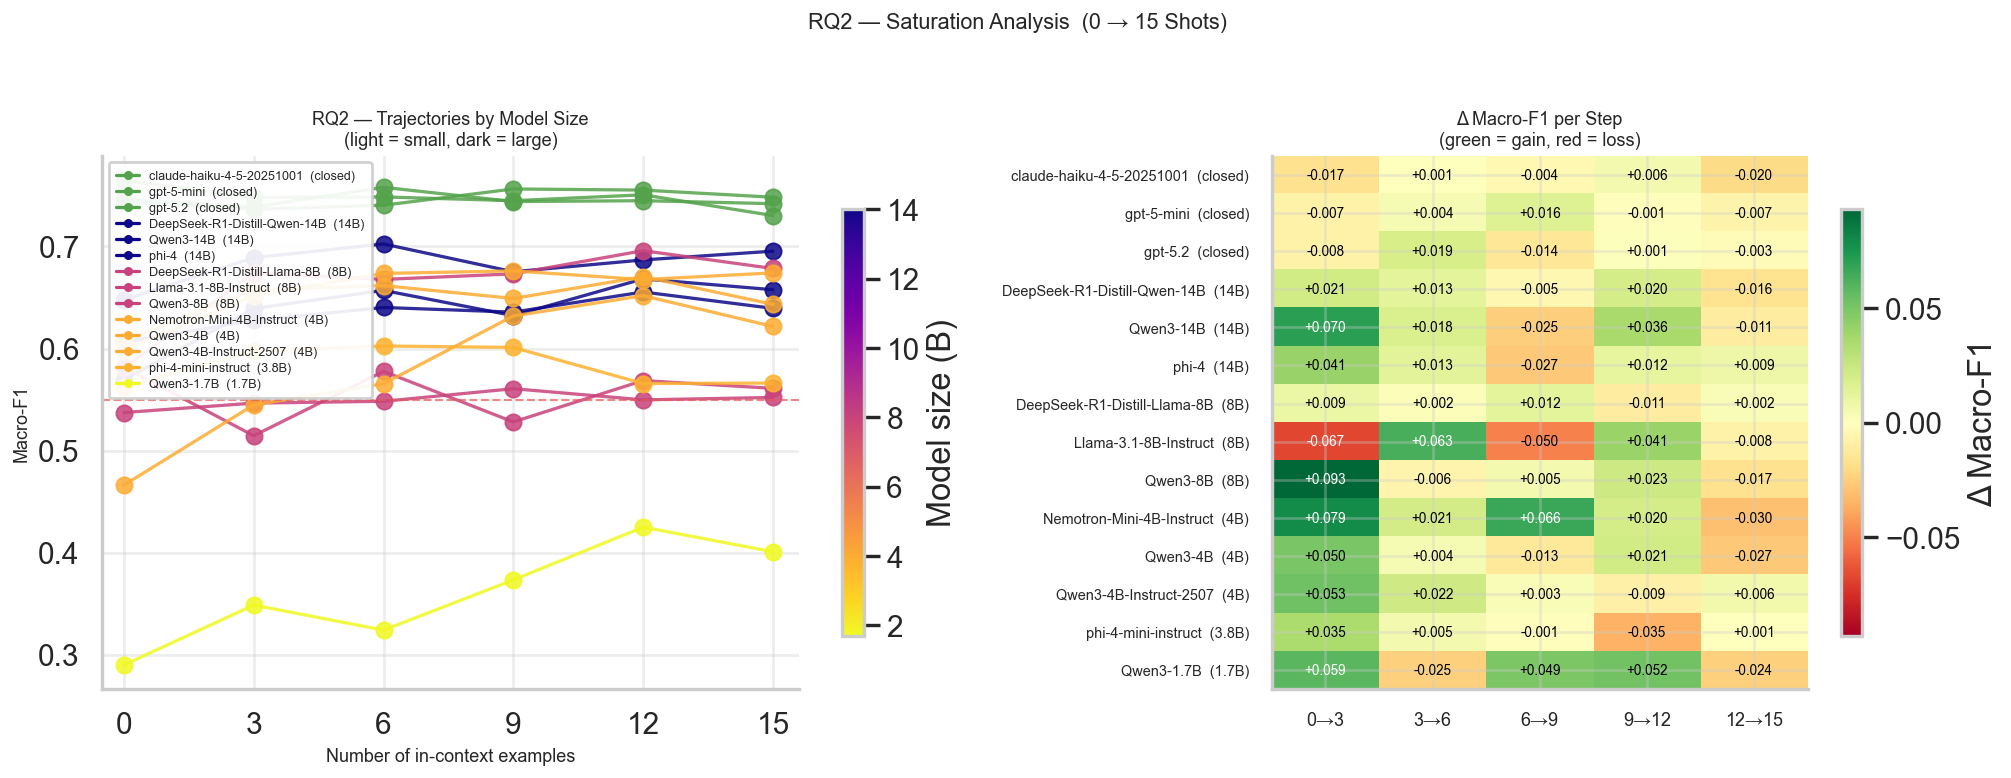

In [91]:
# ── Step-by-step delta heatmap + trajectories coloured by size ───────────
# Adapted from stance_results_team_analysis.ipynb cell 13.

fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                         gridspec_kw={'width_ratios': [1.3, 1]})

# Left: trajectories coloured by model size
ax = axes[0]
known_sizes = step_df['size_B'].dropna()
norm_size = mcolors.Normalize(vmin=known_sizes.min(), vmax=known_sizes.max())
cmap_size  = plt.get_cmap('plasma_r')

traj_handles = []
for _, r in step_df.iterrows():
    model = r['model']
    sub   = metrics[metrics['model'] == model].sort_values('n_shots')
    size  = r['size_B']
    color = cmap_size(norm_size(size)) if pd.notna(size) else '#54A24B'
    line, = ax.plot(sub['n_shots'], sub['macro_f1'], marker='o',
                    color=color, linewidth=1.8, alpha=0.85)
    label_str = f'{model}  ({size:g}B)' if pd.notna(size) else f'{model}  (closed)'
    traj_handles.append(Line2D([0],[0], color=color, marker='o',
                                markersize=4, linewidth=1.8, label=label_str))

ax.axhline(F1_USABLE, color='#E45756', linewidth=1.2, linestyle='--', alpha=0.7)
ax.set_xticks(ICL_SHOT_COUNTS)
ax.set_xlim(-0.5, 15.6)
ax.set_xlabel('Number of in-context examples', fontsize=10)
ax.set_ylabel('Macro-F1', fontsize=10)
ax.set_title('RQ2 \u2014 Trajectories by Model Size\n(light = small, dark = large)', fontsize=10)

sm = plt.cm.ScalarMappable(cmap=cmap_size, norm=norm_size)
sm.set_array([])
plt.colorbar(sm, ax=ax, label='Model size (B)', shrink=0.8)

# Model label legend inside the left axes (upper-left)
ax.legend(handles=traj_handles, fontsize=7, loc='upper left',
          frameon=True, framealpha=0.92, edgecolor='#cccccc',
          borderpad=0.6, labelspacing=0.3, handlelength=1.8,
          ncol=1)

# Right: step delta heatmap
ax2 = axes[1]
heat = step_df[STEP_LABELS].values.astype(float)
row_labels = [
    f'{r["model"]}  ({r["size_B"]:g}B)' if pd.notna(r['size_B'])
    else f'{r["model"]}  (closed)'
    for _, r in step_df.iterrows()
]
non_nan = heat[~np.isnan(heat)]
vlim = max(np.abs(non_nan).max(), 0.01) if len(non_nan) else 0.05
im = ax2.imshow(heat, cmap='RdYlGn', vmin=-vlim, vmax=vlim, aspect='auto')
ax2.set_xticks(range(len(STEP_LABELS)))
ax2.set_xticklabels(STEP_LABELS, fontsize=10)
ax2.set_yticks(range(len(row_labels)))
ax2.set_yticklabels(row_labels, fontsize=8)
ax2.set_title('\u0394 Macro-F1 per Step\n(green = gain, red = loss)', fontsize=10)
for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        val = heat[i, j]
        if not np.isnan(val):
            ax2.text(j, i, f'{val:+.3f}', ha='center', va='center',
                     fontsize=7.5,
                     color='black' if abs(val) < vlim * 0.6 else 'white')
plt.colorbar(im, ax=ax2, label='\u0394 Macro-F1', shrink=0.8)

plt.suptitle('RQ2 \u2014 Saturation Analysis  (0 \u2192 15 Shots)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# ── Table for Delta Heatmap ──────────────────────────────────────────
print("=== Delta Macro-F1 per step (Heatmap RQ2) ===")
_step_tbl = step_df[["model"] + STEP_LABELS].round(3)
display(_step_tbl)
print(_step_tbl.to_csv(index=False))


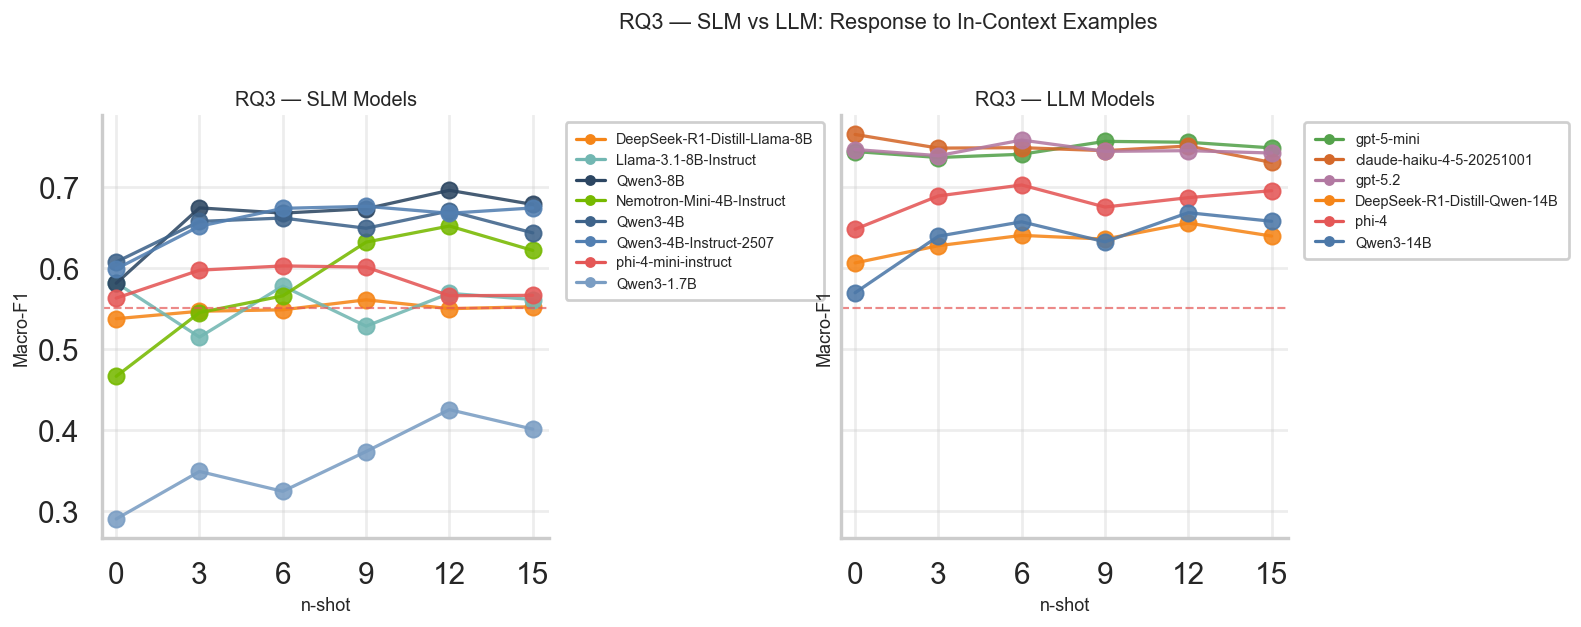

n_shots,0,3,6,9,12,15
tier,,,,,,
LLM,0.680,0.696,0.708,0.698,0.710,0.702
SLM,0.528,0.567,0.578,0.587,0.599,0.587


In [92]:
# ── RQ3: SLM vs LLM trajectories ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for ax, tier in zip(axes, ['SLM', 'LLM']):
    subset_models = sorted(
        metrics[metrics['tier'] == tier]['model'].unique(),
        key=model_sort_key
    )
    colors = build_model_colors(list(subset_models))
    handles = []
    for model in subset_models:
        sub   = metrics[metrics['model'] == model].sort_values('n_shots')
        color = colors.get(model, '#888888')
        ax.plot(sub['n_shots'], sub['macro_f1'], marker='o', color=color,
                linewidth=1.8, alpha=0.88)
        handles.append(Line2D([0],[0], color=color, marker='o',
                               markersize=5, linewidth=1.8, label=model))
    ax.axhline(F1_USABLE, color='#E45756', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_xticks(ICL_SHOT_COUNTS)
    ax.set_xlim(-0.5, 15.6)
    ax.set_xlabel('n-shot', fontsize=10)
    ax.set_ylabel('Macro-F1', fontsize=10)
    ax.set_title(f'RQ3 \u2014 {tier} Models', fontsize=11)
    ax.legend(handles=handles, fontsize=8,
              bbox_to_anchor=(1.02, 1), loc='upper left',
              frameon=True, framealpha=0.94, edgecolor='#cccccc',
              borderpad=0.7, labelspacing=0.45, handlelength=2.0)

plt.suptitle('RQ3 \u2014 SLM vs LLM: Response to In-Context Examples', fontsize=12)
plt.tight_layout()
plt.subplots_adjust(right=0.72)
plt.show()

# ── Group-level mean trajectory ────────────────────────────────────────────
tier_mean = (
    metrics.groupby(['tier', 'n_shots'])['macro_f1']
    .agg(['mean', 'std'])
    .reset_index()
)
display(tier_mean.pivot_table(index='tier', columns='n_shots',
                               values='mean').round(3))

---
## 4 · Per-Class Analysis

**RQ4:** Which stance classes (FAVOR / AGAINST / NONE) benefit most from additional in-context examples?

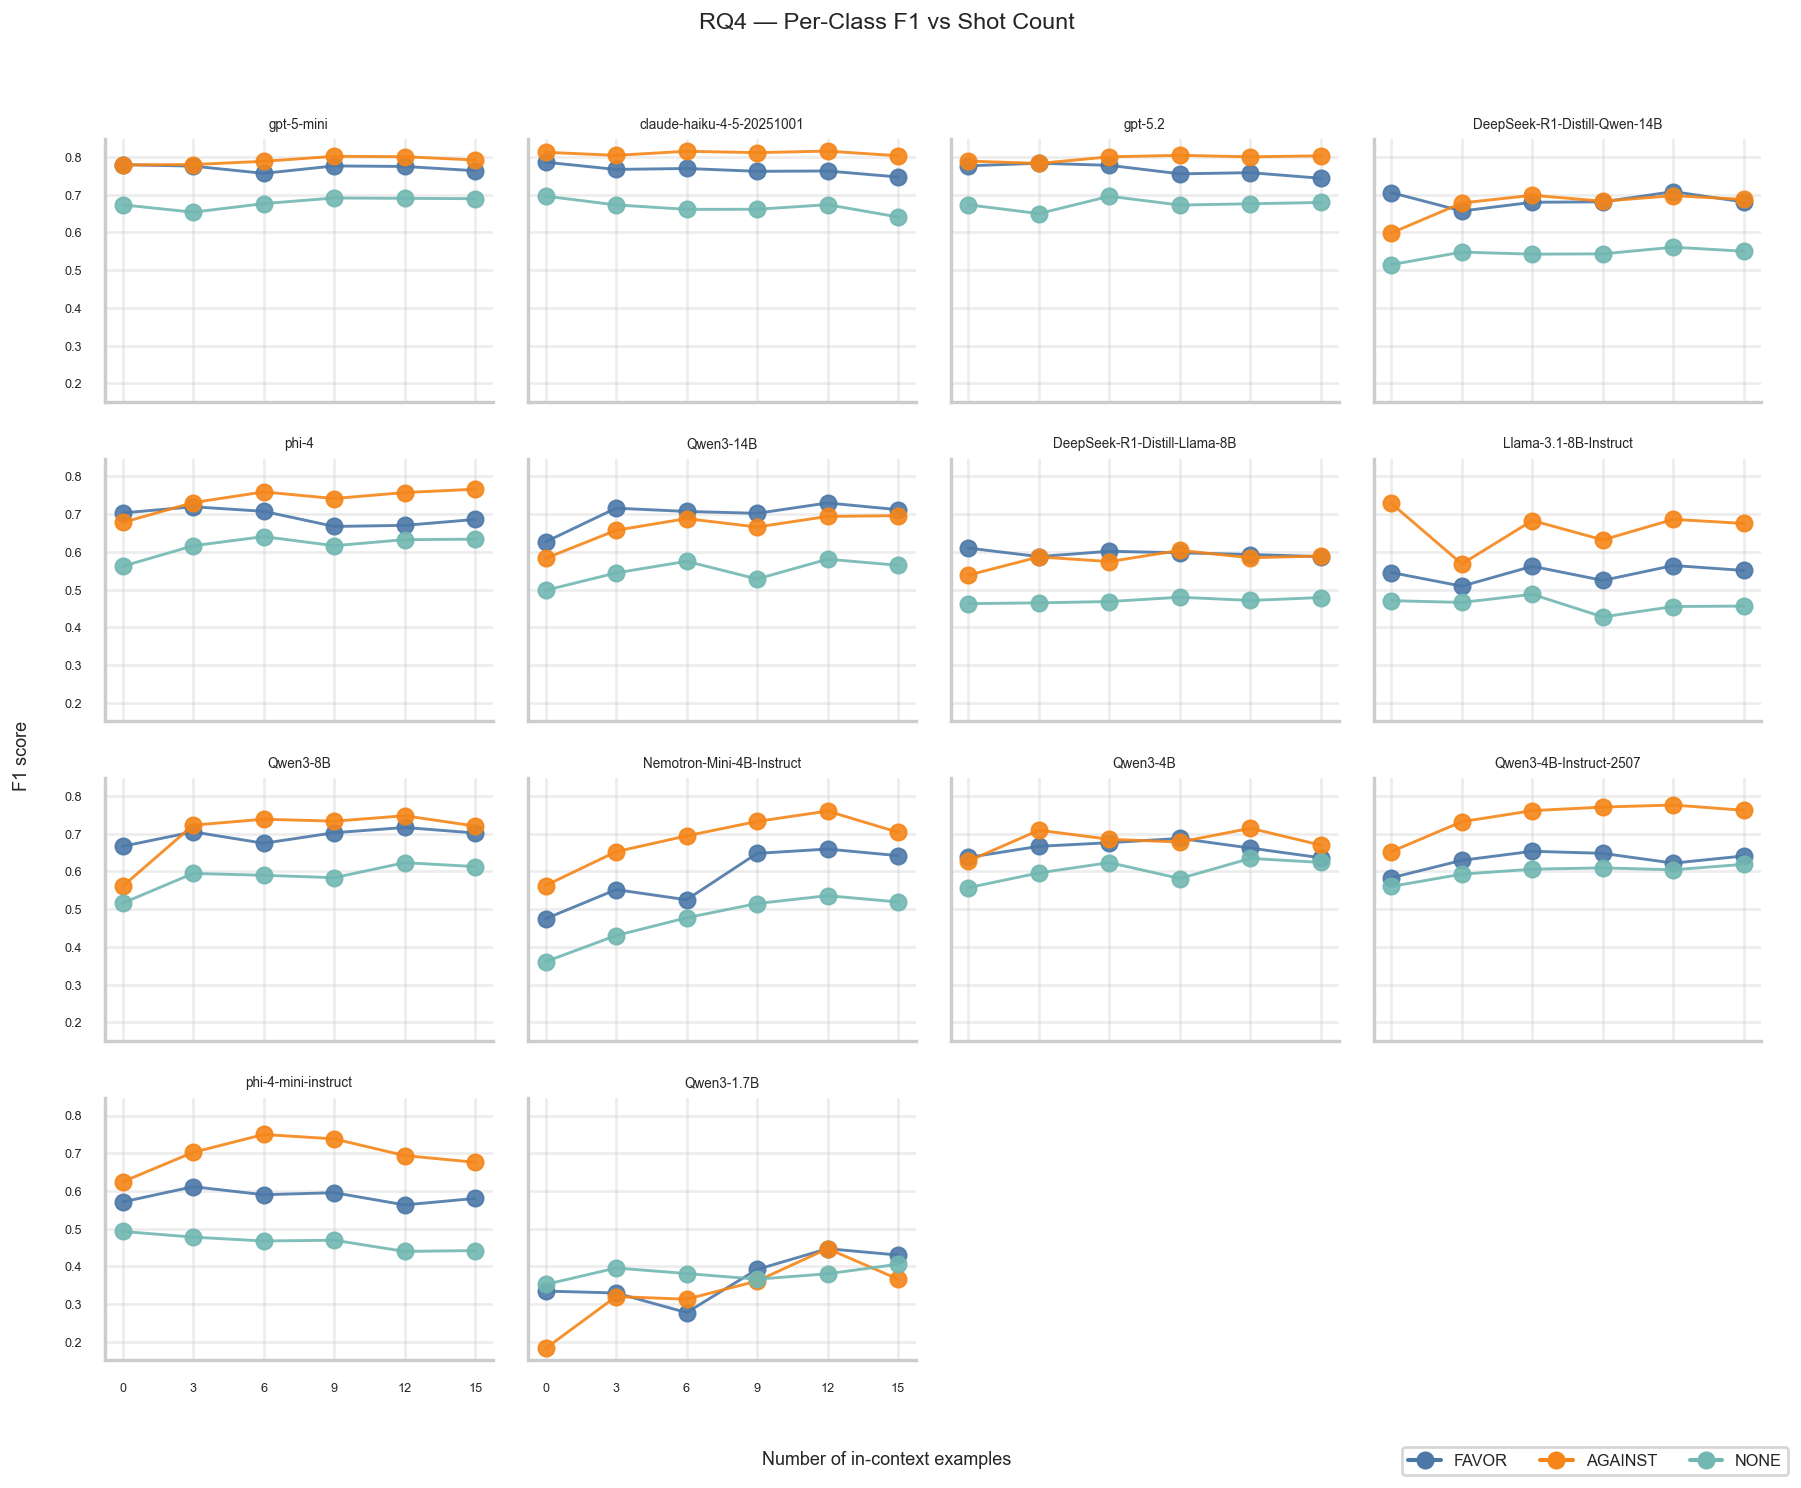

In [93]:
# ── Per-class F1 vs shot count — small multiples per model ───────────────
CLASS_COLORS = {'FAVOR': '#4C78A8', 'AGAINST': '#F58518', 'NONE': '#72B7B2'}

models_sorted = sorted(metrics['model'].unique(), key=model_sort_key)
n_models = len(models_sorted)
ncols = 4
nrows = (n_models + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols,
                         figsize=(ncols * 3.5, nrows * 2.8),
                         sharey=True, sharex=True)
axes_flat = axes.flatten()

for idx, model in enumerate(models_sorted):
    ax  = axes_flat[idx]
    sub = metrics[metrics['model'] == model].sort_values('n_shots')
    for label in LABELS:
        ax.plot(sub['n_shots'], sub[f'f1_{label}'], marker='o',
                color=CLASS_COLORS[label], linewidth=1.6,
                alpha=0.9, label=label)
    ax.set_title(model, fontsize=7.5)
    ax.set_xticks(ICL_SHOT_COUNTS)
    ax.tick_params(labelsize=7)

for idx in range(n_models, len(axes_flat)):
    axes_flat[idx].set_visible(False)

# Shared legend
handles = [Line2D([0],[0], color=CLASS_COLORS[l], marker='o', label=l) for l in LABELS]
fig.legend(handles=handles, loc='lower right', fontsize=9,
           ncol=3, bbox_to_anchor=(1.0, 0.0))
fig.supxlabel('Number of in-context examples', fontsize=10)
fig.supylabel('F1 score', fontsize=10)
fig.suptitle('RQ4 — Per-Class F1 vs Shot Count', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

Mean F1 gain (0→15) per stance class:


,mean,std,min,max
label,,,,
AGAINST,0.071,0.068,-0.053,0.184
FAVOR,0.022,0.060,-0.039,0.167
NONE,0.038,0.057,-0.055,0.158


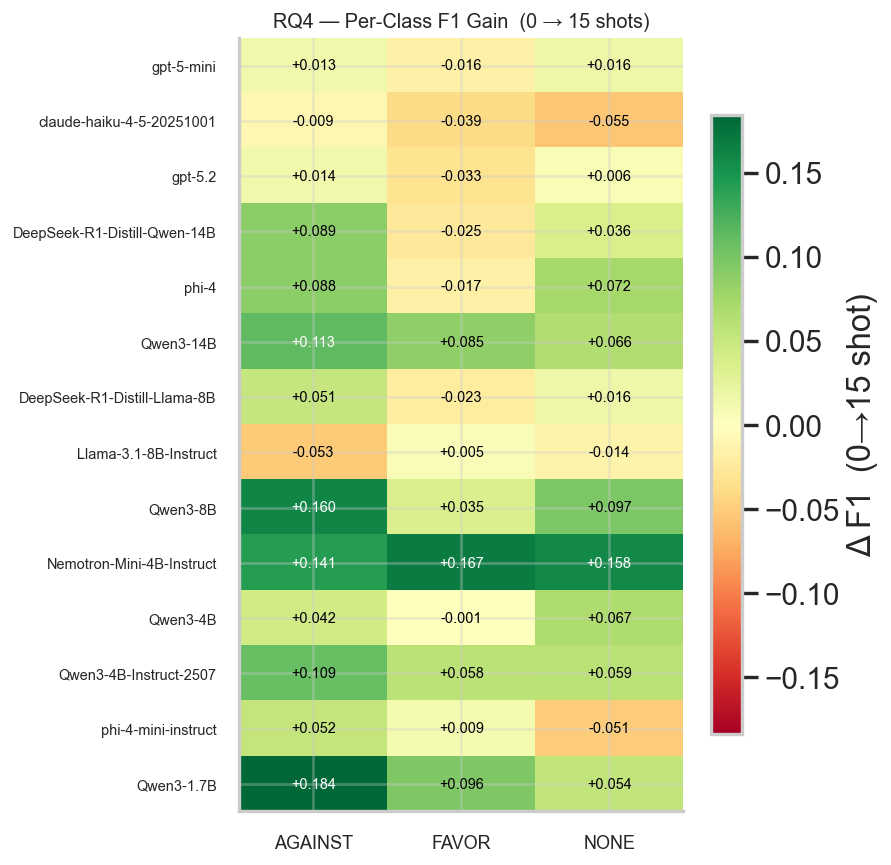

In [94]:
# ── Which class gains the most from 0 → 12 shots? ─────────────────────────
class_gain_rows = []
for model, grp in metrics.groupby('model'):
    grp = grp.set_index('n_shots')
    if 0 not in grp.index or 15 not in grp.index:
        continue
    for label in LABELS:
        col = f'f1_{label}'
        class_gain_rows.append({
            'model': model,
            'label': label,
            'f1_0shot':  grp.loc[0, col],
            'f1_15shot': grp.loc[15, col],
            'gain':      grp.loc[15, col] - grp.loc[0, col],
        })

class_gain_df = pd.DataFrame(class_gain_rows).round(3)

# Mean gain per class across models
print('Mean F1 gain (0→15) per stance class:')
display(
    class_gain_df.groupby('label')['gain']
    .agg(['mean','std','min','max'])
    .round(3)
)

# Heatmap: gain per (model, class)
heat_gain = class_gain_df.pivot(index='model', columns='label', values='gain')
heat_gain = heat_gain.reindex(index=sorted(heat_gain.index, key=model_sort_key))

fig, ax = plt.subplots(figsize=(7, max(4, len(heat_gain) * 0.5)))
vlim = max(heat_gain.abs().max().max(), 0.01)
im = ax.imshow(heat_gain.values, cmap='RdYlGn', vmin=-vlim, vmax=vlim, aspect='auto')
ax.set_xticks(range(len(heat_gain.columns)))
ax.set_xticklabels(heat_gain.columns, fontsize=10)
ax.set_yticks(range(len(heat_gain.index)))
ax.set_yticklabels(heat_gain.index, fontsize=8)
for i in range(heat_gain.shape[0]):
    for j in range(heat_gain.shape[1]):
        val = heat_gain.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                    fontsize=8, color='black' if abs(val) < vlim * 0.6 else 'white')
plt.colorbar(im, ax=ax, label='Δ F1  (0→15 shot)', shrink=0.8)
ax.set_title('RQ4 — Per-Class F1 Gain  (0 → 15 shots)', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
# ── Table for Class Gain Heatmap ─────────────────────────────────────
print("=== Per-class F1 gain (0 → 15 shots) ===")
display(heat_gain.round(3))
print(heat_gain.round(3).to_csv())


---
## 5 · Shot-Sensitive Examples

**RQ5:** What proportion of test examples change prediction as shot count increases?

For each example × model we collect predictions at 0, 3, 6, 9, 12 shots and compute:
- **instability** = number of label flips across consecutive shot counts (0→3, 3→6, …)
- **n_unique_preds** = number of distinct labels predicted across all shot counts
- **error_rate** = fraction of shot counts where prediction ≠ gold

In [95]:
# ── Build wide example × model × shot-count prediction table ─────────────

pred_frames = []
for sys_key, df in system_frames.items():
    model  = sys_key.split(' | ')[0]
    prompt = sys_key.split(' | ')[1]
    n_shots = SHOT_MAP[prompt]
    tmp = df[['doc_id', 'gold', 'pred']].copy()
    tmp['model']   = model
    tmp['n_shots'] = n_shots
    pred_frames.append(tmp)

pred_long = pd.concat(pred_frames, ignore_index=True)

# Pivot to wide: one row per (doc_id, model), one column per shot count
pred_wide = pred_long.pivot_table(
    index=['doc_id', 'model', 'gold'],
    columns='n_shots',
    values='pred',
    aggfunc='first'
).reset_index()
pred_wide.columns.name = None
shot_cols = [c for c in ICL_SHOT_COUNTS if c in pred_wide.columns]

print(f'Rows (doc × model): {len(pred_wide)}')
print(f'Shot columns present: {shot_cols}')
pred_wide.head(3)

Rows (doc × model): 17486
Shot columns present: [0, 3, 6, 9, 12, 15]


,doc_id,model,gold,0,3,6,9,12,15
0,10001,DeepSeek-R1-Distill-Llama-8B,AGAINST,NONE,NONE,NONE,NONE,NONE,NONE
1,10001,DeepSeek-R1-Distill-Qwen-14B,AGAINST,NONE,NONE,NONE,NONE,NONE,NONE
2,10001,Llama-3.1-8B-Instruct,AGAINST,AGAINST,FAVOR,AGAINST,AGAINST,AGAINST,AGAINST


In [96]:
# ── Compute per-row instability metrics ───────────────────────────────────

def count_flips(row, cols):
    """Number of label changes across consecutive shot counts."""
    preds = [row[c] for c in cols if not pd.isna(row[c])]
    return sum(a != b for a, b in zip(preds, preds[1:]))

def n_unique(row, cols):
    preds = [row[c] for c in cols if not pd.isna(row[c])]
    return len(set(preds))

def error_rate(row, cols):
    preds = [row[c] for c in cols if not pd.isna(row[c])]
    if not preds:
        return np.nan
    return sum(p != row['gold'] for p in preds) / len(preds)

pred_wide['instability']   = pred_wide.apply(count_flips,  cols=shot_cols, axis=1)
pred_wide['n_unique_preds']= pred_wide.apply(n_unique,     cols=shot_cols, axis=1)
pred_wide['error_rate']    = pred_wide.apply(error_rate,   cols=shot_cols, axis=1)
pred_wide['any_change']    = pred_wide['instability'] > 0
pred_wide['multi_change']  = pred_wide['instability'] > 1
pred_wide['always_stable'] = pred_wide['instability'] == 0

pred_wide.head(3)

,doc_id,model,gold,0,3,6,9,12,15,instability,n_unique_preds,error_rate,any_change,multi_change,always_stable
0,10001,DeepSeek-R1-Distill-Llama-8B,AGAINST,NONE,NONE,NONE,NONE,NONE,NONE,0,1,1.000,False,False,True
1,10001,DeepSeek-R1-Distill-Qwen-14B,AGAINST,NONE,NONE,NONE,NONE,NONE,NONE,0,1,1.000,False,False,True
2,10001,Llama-3.1-8B-Instruct,AGAINST,AGAINST,FAVOR,AGAINST,AGAINST,AGAINST,AGAINST,2,2,0.167,True,True,False


In [97]:
# ── Per-model summary ─────────────────────────────────────────────────────
stability_summary = (
    pred_wide.groupby('model')
    .agg(
        pct_any_change   = ('any_change',    'mean'),
        pct_multi_change = ('multi_change',  'mean'),
        pct_stable       = ('always_stable', 'mean'),
        mean_instability = ('instability',   'mean'),
        mean_error_rate  = ('error_rate',    'mean'),
    )
    .reset_index()
    .sort_values('mean_instability', ascending=False)
)
stability_summary[['pct_any_change','pct_multi_change','pct_stable']] *= 100
stability_summary = stability_summary.round(2)
display(stability_summary)

,model,pct_any_change,pct_multi_change,pct_stable,mean_instability,mean_error_rate
0,DeepSeek-R1-Distill-Llama-8B,50.200,36.190,49.800,1.140,0.450
6,Qwen3-4B,45.560,32.430,54.440,1.000,0.350
4,Qwen3-1.7B,51.000,33.550,49.000,0.960,0.640
3,Nemotron-Mini-4B-Instruct,51.560,28.820,48.440,0.960,0.390
2,Llama-3.1-8B-Instruct,54.360,21.460,45.640,0.910,0.410
8,Qwen3-8B,40.910,24.020,59.090,0.800,0.330
1,DeepSeek-R1-Distill-Qwen-14B,35.390,24.980,64.610,0.770,0.360
13,phi-4-mini-instruct,44.440,19.140,55.560,0.720,0.380
5,Qwen3-14B,32.430,20.980,67.570,0.670,0.360
7,Qwen3-4B-Instruct-2507,31.550,13.130,68.450,0.520,0.320


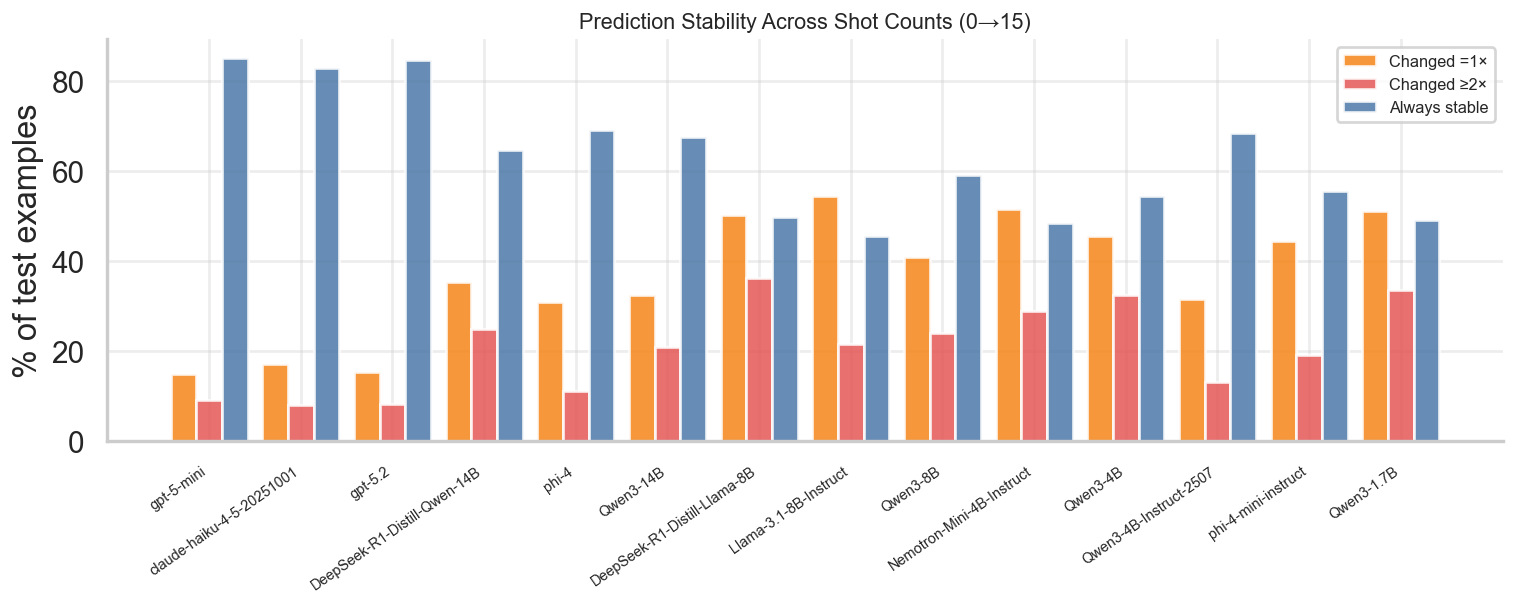

In [98]:
# ── Bar chart: % examples that change prediction ──────────────────────────
stab = stability_summary.sort_values('model', key=lambda s: s.map(model_sort_key))

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(stab))
w = 0.28
ax.bar(x - w,   stab['pct_any_change'],   width=w, label='Changed =1×', color='#F58518', alpha=0.85)
ax.bar(x,       stab['pct_multi_change'], width=w, label='Changed ≥2×', color='#E45756', alpha=0.85)
ax.bar(x + w,   stab['pct_stable'],       width=w, label='Always stable', color='#4C78A8', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(stab['model'], rotation=35, ha='right', fontsize=8)
ax.set_ylabel('% of test examples')
ax.set_title('Prediction Stability Across Shot Counts (0→15)', fontsize=12)
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 6 · Helped vs Harmed Examples

**RQ6:** Which examples are corrected by more shots, and which are harmed?

We classify each (example, model) pair into five categories:  
- **stable_correct** — always predicted correctly  
- **stable_wrong** — always predicted incorrectly  
- **corrected** — wrong at 0-shot, correct at 15-shot  
- **harmed** — correct at 0-shot, wrong at 15-shot  
- **unstable** — prediction flips more than once  

*Note: 0-shot = `task_definition`; 15-shot = `few_shot_15`.*

In [99]:
# ── Classify each (doc, model) pair ──────────────────────────────────────

def classify_trajectory(row, shot_cols, gold_col='gold'):
    gold       = row[gold_col]
    pred_0     = row.get(0)   if 0  in shot_cols else np.nan
    pred_15    = row.get(15)  if 15 in shot_cols else np.nan
    flips      = row['instability']

    if pd.isna(pred_0) or pd.isna(pred_15):
        return 'incomplete'
    correct_0  = pred_0  == gold
    correct_15 = pred_15 == gold

    if flips > 1:
        return 'unstable'
    if correct_0 and correct_15:
        return 'stable_correct'
    if not correct_0 and not correct_15:
        return 'stable_wrong'
    if not correct_0 and correct_15:
        return 'corrected'
    if correct_0 and not correct_15:
        return 'harmed'
    return 'other'

pred_wide['trajectory'] = pred_wide.apply(
    classify_trajectory, shot_cols=shot_cols, axis=1
)

traj_summary = (
    pred_wide.groupby(['model', 'trajectory'])
    .size()
    .reset_index(name='count')
    .pivot_table(index='model', columns='trajectory', values='count', fill_value=0)
)
traj_pct = traj_summary.div(traj_summary.sum(axis=1), axis=0) * 100
traj_pct = traj_pct.reindex(
    sorted(traj_pct.index, key=model_sort_key)
).round(1)

print('Trajectory breakdown (% of test examples per model):')
display(traj_pct)

Trajectory breakdown (% of test examples per model):


trajectory,corrected,harmed,incomplete,stable_correct,stable_wrong,unstable
model,,,,,,
gpt-5-mini,3.000,1.800,5.800,64.800,16.100,8.600
claude-haiku-4-5-20251001,3.200,4.600,1.400,68.100,15.100,7.700
gpt-5.2,2.900,2.600,2.500,66.900,17.000,8.200
DeepSeek-R1-Distill-Qwen-14B,6.600,2.600,0.000,47.400,18.500,25.000
phi-4,11.000,5.000,0.000,54.200,18.500,11.200
Qwen3-14B,8.500,1.400,0.100,48.500,20.600,21.000
DeepSeek-R1-Distill-Llama-8B,7.200,4.700,0.200,31.800,19.900,36.200
Llama-3.1-8B-Instruct,12.000,14.800,0.000,35.100,16.600,21.500
Qwen3-8B,11.900,3.100,0.700,45.500,14.800,23.900


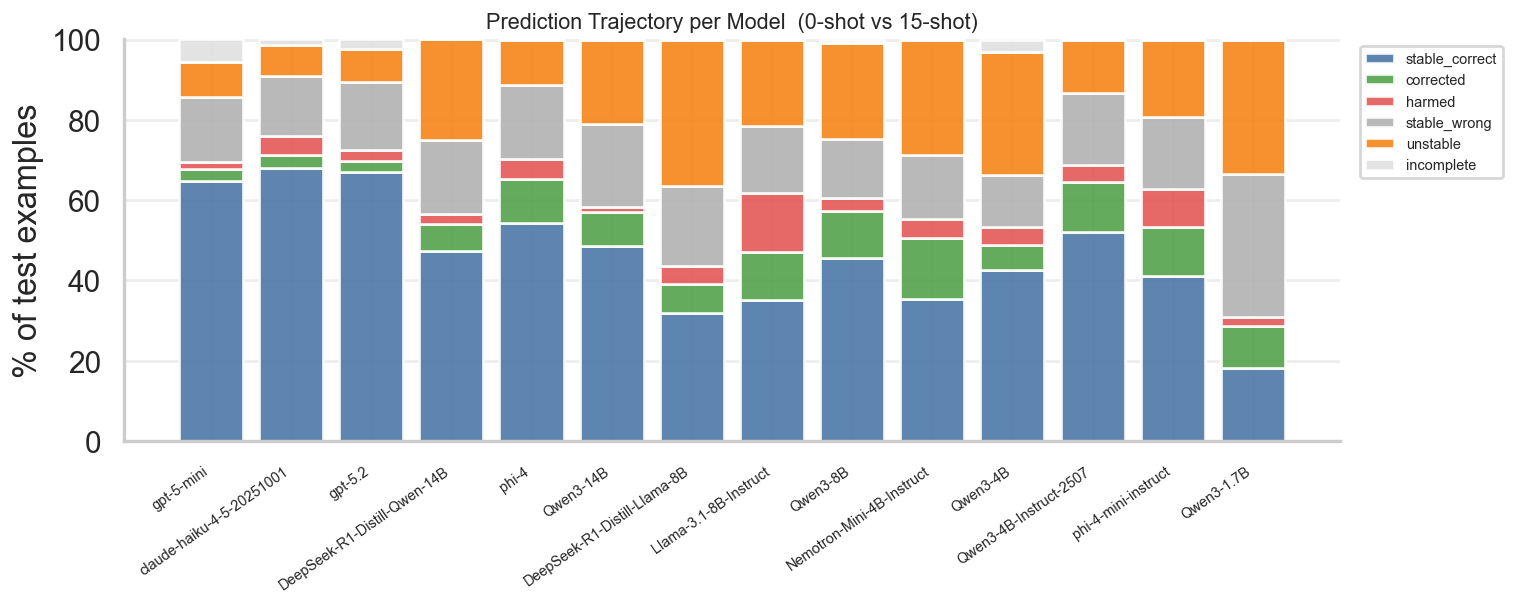

In [100]:
# ── Stacked bar: trajectory breakdown per model ───────────────────────────
TRAJ_COLORS = {
    'stable_correct': '#4C78A8',
    'corrected':      '#54A24B',
    'harmed':         '#E45756',
    'stable_wrong':   '#B2B2B2',
    'unstable':       '#F58518',
    'incomplete':     '#E0E0E0',
}
plot_cols = [c for c in TRAJ_COLORS if c in traj_pct.columns]

fig, ax = plt.subplots(figsize=(12, 5))
bottom = np.zeros(len(traj_pct))
for col in plot_cols:
    vals = traj_pct[col].values if col in traj_pct.columns else np.zeros(len(traj_pct))
    ax.bar(traj_pct.index, vals, bottom=bottom,
           color=TRAJ_COLORS[col], label=col, alpha=0.9)
    bottom += vals

ax.set_xticklabels(traj_pct.index, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('% of test examples')
ax.set_title('Prediction Trajectory per Model  (0-shot vs 15-shot)', fontsize=12)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [101]:
# ── Corrected vs harmed — which gold classes are involved? ────────────────
for traj in ['corrected', 'harmed']:
    sub = pred_wide[pred_wide['trajectory'] == traj]
    if len(sub) == 0:
        print(f'No examples classified as "{traj}".')
        continue
    print(f'\n--- {traj.upper()} examples: gold label distribution ---')
    print(sub.groupby(['model', 'gold']).size()
             .unstack(fill_value=0)
             .reindex(sorted(sub['model'].unique(), key=model_sort_key))
             .to_string())


--- CORRECTED examples: gold label distribution ---
gold                          AGAINST  FAVOR  NONE
model                                             
gpt-5-mini                         25      7     5
claude-haiku-4-5-20251001          27     11     2
gpt-5.2                            23      7     6
DeepSeek-R1-Distill-Qwen-14B       61     16     5
phi-4                             103     35     0
Qwen3-14B                          70     33     3
DeepSeek-R1-Distill-Llama-8B       56     15    19
Llama-3.1-8B-Instruct              39    108     3
Qwen3-8B                          125     23     1
Nemotron-Mini-4B-Instruct         109     47    33
Qwen3-4B                           43     24     9
Qwen3-4B-Instruct-2507            124     25     6
phi-4-mini-instruct               103     51     1
Qwen3-1.7B                         80     42     9

--- HARMED examples: gold label distribution ---
gold                          AGAINST  FAVOR  NONE
model                         

---
## 7 · Cross-Model Example Analysis

**RQ7 / RQ8:** Which examples remain unstable across shot counts *and* across models?  
Are there examples that are difficult mainly for SLMs but not for LLMs?

We build an example-level table aggregating signals across all models.

In [102]:
# ── Aggregate per-example across models ──────────────────────────────────
n_models_total = pred_wide['model'].nunique()

example_agg = (
    pred_wide.groupby('doc_id')
    .agg(
        gold            = ('gold',          'first'),
        n_models_any_change = ('any_change',    'sum'),
        n_models_wrong_15   = (15,              lambda x: (x != pred_wide.loc[x.index, 'gold']).sum()),
        n_models_corrected  = ('trajectory',    lambda x: (x == 'corrected').sum()),
        n_models_harmed     = ('trajectory',    lambda x: (x == 'harmed').sum()),
        n_models_unstable   = ('trajectory',    lambda x: (x == 'unstable').sum()),
        mean_error_rate     = ('error_rate',    'mean'),
        mean_instability    = ('instability',   'mean'),
    )
    .reset_index()
)

# SLM-specific vs LLM-specific difficulty
slm_models = [m for m in pred_wide['model'].unique() if is_slm(m)]
llm_models = [m for m in pred_wide['model'].unique() if is_llm(m)]

for tier_name, tier_models in [('slm', slm_models), ('llm', llm_models)]:
    tier_sub = pred_wide[pred_wide['model'].isin(tier_models)]
    tier_agg = (
        tier_sub.groupby('doc_id')
        .agg(**{f'mean_err_{tier_name}': ('error_rate', 'mean')})
        .reset_index()
    )
    example_agg = example_agg.merge(tier_agg, on='doc_id', how='left')

# Hard mainly for SLMs: high SLM error rate AND low LLM error rate
if 'mean_err_slm' in example_agg.columns and 'mean_err_llm' in example_agg.columns:
    example_agg['slm_only_hard'] = (
        (example_agg['mean_err_slm'] > 0.5) &
        (example_agg['mean_err_llm'] < 0.3)
    )
    example_agg['llm_only_hard'] = (
        (example_agg['mean_err_llm'] > 0.5) &
        (example_agg['mean_err_slm'] < 0.3)
    )

example_agg = example_agg.round(3)
print(f'Total unique examples: {len(example_agg)}')
example_agg.sort_values('mean_instability', ascending=False).head(10)

Total unique examples: 1249


,doc_id,gold,n_models_any_change,n_models_wrong_15,n_models_corrected,n_models_harmed,n_models_unstable,mean_error_rate,mean_instability,mean_err_slm,mean_err_llm,slm_only_hard,llm_only_hard
447,10448,AGAINST,12,8,2,0,10,0.595,2.500,0.562,0.639,False,False
336,10337,FAVOR,12,11,0,0,12,0.643,2.143,0.792,0.444,False,False
443,10444,AGAINST,10,9,1,1,8,0.536,2.000,0.604,0.444,False,False
668,10669,FAVOR,11,3,1,1,9,0.464,2.000,0.500,0.417,False,False
495,10496,FAVOR,12,7,2,1,8,0.548,1.929,0.625,0.444,False,False
1001,11002,NONE,13,11,0,3,8,0.640,1.929,0.579,0.722,False,False
1174,11175,FAVOR,9,5,0,1,8,0.429,1.929,0.583,0.222,True,False
344,10345,FAVOR,12,6,4,0,6,0.374,1.929,0.312,0.456,False,False
558,10559,AGAINST,11,10,0,4,7,0.500,1.929,0.688,0.250,True,False
897,10898,AGAINST,10,10,0,2,7,0.629,1.857,0.667,0.578,False,False


In [103]:
# ── Top-N most shot-sensitive examples (ranked by mean instability) ───────
TOP_N = 20

top_unstable = example_agg.nlargest(TOP_N, 'mean_instability')
print(f'Top {TOP_N} most shot-sensitive examples (highest mean instability across models):')
display(top_unstable[['doc_id', 'gold', 'n_models_any_change',
                       'n_models_wrong_15', 'n_models_corrected',
                       'n_models_harmed', 'n_models_unstable',
                       'mean_error_rate', 'mean_instability']])

Top 20 most shot-sensitive examples (highest mean instability across models):


,doc_id,gold,n_models_any_change,n_models_wrong_15,n_models_corrected,n_models_harmed,n_models_unstable,mean_error_rate,mean_instability
447,10448,AGAINST,12,8,2,0,10,0.595,2.500
336,10337,FAVOR,12,11,0,0,12,0.643,2.143
443,10444,AGAINST,10,9,1,1,8,0.536,2.000
668,10669,FAVOR,11,3,1,1,9,0.464,2.000
344,10345,FAVOR,12,6,4,0,6,0.374,1.929
495,10496,FAVOR,12,7,2,1,8,0.548,1.929
558,10559,AGAINST,11,10,0,4,7,0.500,1.929
1001,11002,NONE,13,11,0,3,8,0.640,1.929
1174,11175,FAVOR,9,5,0,1,8,0.429,1.929
897,10898,AGAINST,10,10,0,2,7,0.629,1.857


In [104]:
# ── RQ8: Examples hard mainly for SLMs ───────────────────────────────────
if 'slm_only_hard' in example_agg.columns:
    slm_hard = example_agg[example_agg['slm_only_hard']]
    print(f'Examples hard for SLMs but not LLMs: {len(slm_hard)}')
    display(slm_hard[['doc_id', 'gold', 'mean_err_slm', 'mean_err_llm',
                       'mean_instability']].head(20))
else:
    print('SLM/LLM split unavailable — check that both tier groups have results.')

# Distribution of gold labels among SLM-hard examples
if 'slm_only_hard' in example_agg.columns and len(slm_hard) > 0:
    print('\nGold label distribution in SLM-hard examples:')
    print(slm_hard['gold'].value_counts().to_string())

Examples hard for SLMs but not LLMs: 110


,doc_id,gold,mean_err_slm,mean_err_llm,mean_instability
37,10038,AGAINST,0.729,0.167,1.500
39,10040,AGAINST,0.542,0.167,1.071
58,10059,AGAINST,0.646,0.056,0.571
66,10067,AGAINST,0.521,0.167,1.071
71,10072,FAVOR,0.625,0.028,0.714
78,10079,AGAINST,0.583,0.194,0.857
105,10106,AGAINST,0.562,0.222,0.857
121,10122,FAVOR,0.625,0.000,0.643
130,10131,FAVOR,0.571,0.172,1.571
148,10149,AGAINST,0.521,0.283,1.214



Gold label distribution in SLM-hard examples:
gold
AGAINST    52
FAVOR      32
NONE       26


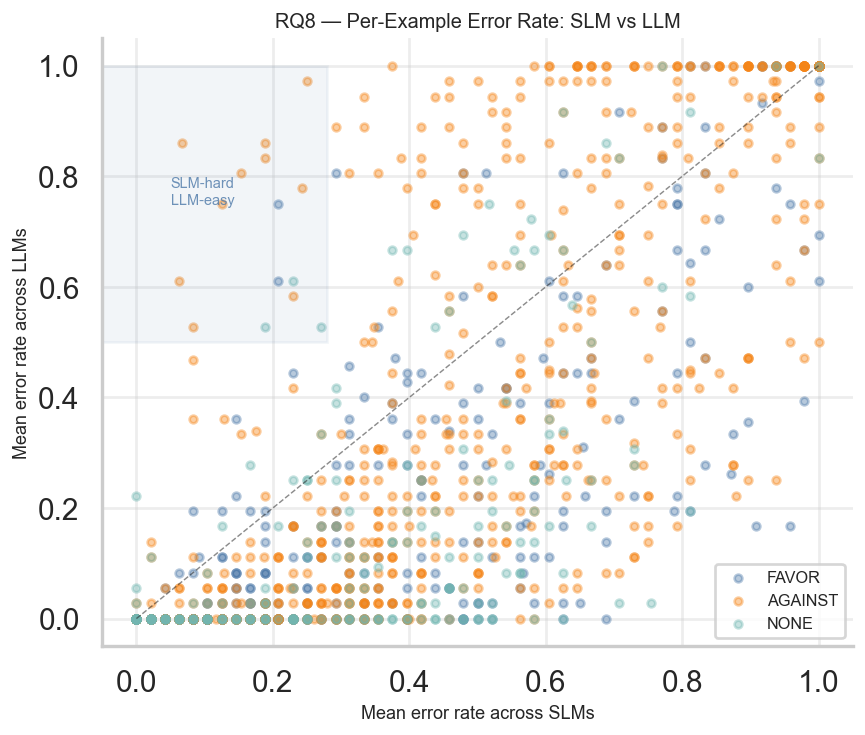

In [105]:
# ── Scatter: SLM error rate vs LLM error rate (per example) ──────────────
if 'mean_err_slm' in example_agg.columns and 'mean_err_llm' in example_agg.columns:
    label_colors = {'FAVOR': '#4C78A8', 'AGAINST': '#F58518', 'NONE': '#72B7B2'}
    plot_df = example_agg.dropna(subset=['mean_err_slm', 'mean_err_llm'])

    fig, ax = plt.subplots(figsize=(7, 6))
    for label in LABELS:
        sub = plot_df[plot_df['gold'] == label]
        ax.scatter(sub['mean_err_slm'], sub['mean_err_llm'],
                   color=label_colors[label], alpha=0.4, s=18, label=label)

    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, alpha=0.5)
    ax.axhspan(0.5, 1.0, xmin=0.0, xmax=0.3, color='#4C78A8', alpha=0.07)
    ax.text(0.05, 0.75, 'SLM-hard\nLLM-easy', fontsize=8, color='#4C78A8', alpha=0.8)
    ax.set_xlabel('Mean error rate across SLMs', fontsize=10)
    ax.set_ylabel('Mean error rate across LLMs', fontsize=10)
    ax.set_title('RQ8 — Per-Example Error Rate: SLM vs LLM', fontsize=11)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

---
## 8 · Qualitative Inspection

This section prints the most interesting examples in a human-readable format so that a researcher can manually inspect them.

The data contains `content` (tweet text) and `query` (target topic) columns which we use here.

> **Note:** If `content` is missing from the loaded data (e.g., because the pipeline was run without storing the raw text), you will see `[content not available]`. In that case, you can join on `doc_id` against the original gold dataset at `data_in/semeval2016_task6_testdata_gold`.

In [106]:
# ── Build a lookup: doc_id → (content, query) ─────────────────────────────
# We grab these fields from any available result frame that contains them.

doc_meta = {}  # doc_id -> {'content': ..., 'query': ...}
for sys_key, df in system_frames.items():
    for _, row in df.iterrows():
        did = str(row['doc_id'])
        if did not in doc_meta:
            doc_meta[did] = {
                'content': row.get('content', '[content not available]'),
                'query':   row.get('query',   '[query not available]'),
            }

print(f'doc_meta entries: {len(doc_meta)}')
# sample
sample_id = list(doc_meta.keys())[0]
print(f'\nSample doc_id={sample_id}:', doc_meta[sample_id])

doc_meta entries: 1249

Sample doc_id=10001: {'content': 'He who exalts himself shall be humbled; and he who humbles himself shall be exalted.Matt 23:12.     #SemST', 'query': 'Atheism'}


In [107]:
# ── Helper to display predictions across shots for a list of doc_ids ──────

def inspect_examples(doc_ids, title='Examples', models=None, max_models=6):
    """Print text, target, gold label, and per-model shot predictions."""
    if models is None:
        models = sorted(pred_wide['model'].unique(), key=model_sort_key)[:max_models]

    print(f'{'='*80}')
    print(f'  {title}')
    print(f'{'='*80}')
    for doc_id in doc_ids:
        meta  = doc_meta.get(str(doc_id), {})
        rows  = pred_wide[pred_wide['doc_id'].astype(str) == str(doc_id)]
        gold  = rows['gold'].values[0] if len(rows) else '?'

        print(f'\ndoc_id : {doc_id}')
        print(f'target : {meta.get("query", "[n/a]")}')
        print(f'gold   : {gold}')
        print(f'text   : {str(meta.get("content", "[n/a]"))[:140]}')
        print(f'{"-"*60}')
        print(f'  {"Model":<42}', end='')
        for s in shot_cols:
            print(f'{s:>8}-shot', end='')
        print()
        for model in models:
            row = rows[rows['model'] == model]
            if len(row) == 0:
                continue
            row = row.iloc[0]
            print(f'  {model:<42}', end='')
            for s in shot_cols:
                pred = row.get(s, '—')
                marker = '✓' if pred == gold else '✗'
                print(f'{str(pred)+marker:>12}', end='')
            print()

In [108]:
# ── 8a: Most shot-sensitive examples (highest mean instability) ───────────
top_ids = example_agg.nlargest(10, 'mean_instability')['doc_id'].tolist()
inspect_examples(top_ids, title='Top-10 Most Shot-Sensitive Examples (all models)')

  Top-10 Most Shot-Sensitive Examples (all models)

doc_id : 10448
target : Feminist Movement
gold   : AGAINST
text   : Really great to see people cheering for Hope Solo even though she has been involved in domestic abuse #equality #SemST
------------------------------------------------------------
  Model                                            0-shot       3-shot       6-shot       9-shot      12-shot      15-shot
  gpt-5-mini                                       NONE✗       NONE✗       NONE✗      FAVOR✗    AGAINST✓      FAVOR✗
  claude-haiku-4-5-20251001                        NONE✗    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓
  gpt-5.2                                          NONE✗      FAVOR✗    AGAINST✓    AGAINST✓      FAVOR✗       NONE✗
  DeepSeek-R1-Distill-Qwen-14B                    FAVOR✗      FAVOR✗       NONE✗       NONE✗      FAVOR✗    AGAINST✓
  phi-4                                            NONE✗    AGAINST✓    AGAINST✓       NONE✗    AGAINST✓    A

In [109]:
# ── 8b: Examples corrected by more shots (most corrected across models) ───
corrected_ids = (
    example_agg.nlargest(8, 'n_models_corrected')['doc_id'].tolist()
)
inspect_examples(corrected_ids, title='Top-8 Examples Most Corrected by More Shots')

  Top-8 Examples Most Corrected by More Shots

doc_id : 10198
target : Atheism
gold   : AGAINST
text   : Give us the gifts and graces to be your vessels. Amen #SemST
------------------------------------------------------------
  Model                                            0-shot       3-shot       6-shot       9-shot      12-shot      15-shot
  gpt-5-mini                                    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓
  claude-haiku-4-5-20251001                     AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓
  gpt-5.2                                       AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓
  DeepSeek-R1-Distill-Qwen-14B                     NONE✗    AGAINST✓       NONE✗    AGAINST✓    AGAINST✓    AGAINST✓
  phi-4                                            NONE✗    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓    AGAINST✓
  Qwen3-14B                                       FAVOR✗    AGAIN

In [110]:
# ── 8c: Examples harmed by more shots (most harmed across models) ─────────
harmed_ids = (
    example_agg.nlargest(8, 'n_models_harmed')['doc_id'].tolist()
)
inspect_examples(harmed_ids, title='Top-8 Examples Most Harmed by More Shots')

  Top-8 Examples Most Harmed by More Shots

doc_id : 10724
target : Hillary Clinton
gold   : NONE
text   : AKA Depends Day "It all depends" and Owebama's positions make you fill your Depends. @jjauthor @weknowwhatsbest #SemST
------------------------------------------------------------
  Model                                            0-shot       3-shot       6-shot       9-shot      12-shot      15-shot
  gpt-5-mini                                       NONE✓    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗
  claude-haiku-4-5-20251001                        NONE✓    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗
  gpt-5.2                                          NONE✓    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗
  DeepSeek-R1-Distill-Qwen-14B                     NONE✓       NONE✓       NONE✓    AGAINST✗    AGAINST✗       NONE✓
  phi-4                                            NONE✓    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗    AGAINST✗
  Qwe

In [111]:
# ── 8d: Examples hard for SLMs but not LLMs ──────────────────────────────
if 'slm_only_hard' in example_agg.columns:
    slm_hard_ids = (
        example_agg[example_agg['slm_only_hard']]
        .nlargest(8, 'mean_err_slm')['doc_id'].tolist()
    )
    inspect_examples(slm_hard_ids,
                     title='Top-8 Examples Hard for SLMs but Easy for LLMs')
else:
    print('SLM-specific difficulty analysis not available.')

  Top-8 Examples Hard for SLMs but Easy for LLMs

doc_id : 11123
target : Legalization of Abortion
gold   : FAVOR
text   : Yea, let's make a woman suffer 18 years and raise a child with an unfit parent who hates it because of "morality". #SemST
------------------------------------------------------------
  Model                                            0-shot       3-shot       6-shot       9-shot      12-shot      15-shot
  gpt-5-mini                                      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓
  claude-haiku-4-5-20251001                       FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓
  gpt-5.2                                         FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓
  DeepSeek-R1-Distill-Qwen-14B                  AGAINST✗    AGAINST✗      FAVOR✓    AGAINST✗    AGAINST✗    AGAINST✗
  phi-4                                           FAVOR✓      FAVOR✓      FAVOR✓      FAVOR✓      FAVOR

---
## Summary of Key Findings

| # | Research question | Key result |
|---|-------------------|------------|
| 1 | **Performance vs shot count** | Performance improves for 11/13 models from 0→12 shots. Gains range from +0.003 (gpt-5.2) to +0.167 (Nemotron-4B). Most gain happens in the first 0→3 step. Two models regress: Llama-3.1-8B drops from 0.582 to 0.476 at 3-shot before recovering to 0.579 at 12-shot; DeepSeek-R1-Llama-8B is non-monotonic (best at 3-shot, 0.580). |
| 2 | **Saturation** | 10/13 models saturate by 6-shot (\|Δ\| < 0.01 after that). Qwen3-8B and Qwen3-1.7B are exceptions, still improving at 9→12. Best shot count varies: most models peak at 6–9. gpt-5-mini and gpt-5.2 are already near-saturated at 0-shot — extra examples add almost nothing (+0.010 and −0.005 respectively). |
| 3 | **SLM vs LLM** | LLMs start much higher (0.663 vs 0.528 at 0-shot) and gain mostly from the 0→3 step (+0.029), then plateau. SLMs gain more steadily across the full range (+0.063 total vs +0.035 for LLMs). SLMs are also far more unstable: only 52–74% of their predictions are stable vs 86–88% for gpt-5. |
| 4 | **Per-class benefit** | AGAINST benefits the most from more shots (mean Δ F1 = +0.076), followed by FAVOR (+0.041) and NONE (+0.039). NONE is the hardest class and the least responsive — extra shots often push models away from NONE incorrectly. |
| 5 | **Prediction stability** | 12–54% of test examples change prediction at least once, depending on model. DeepSeek-R1-Llama-8B and Llama-3.1-8B are most unstable (~48–54% flip ≥1×). gpt-5-mini is most stable (87.8% never change). Multi-flip instability is highest for DeepSeek-R1-Llama-8B (33.5%). |
| 6 | **Helped vs harmed** | 3–20% of examples are corrected by more shots; 1–13% are harmed. Nemotron-4B has the best correction rate (19.8% corrected, 5.3% harmed). Llama-3.1-8B is the only model where harmed > corrected (13.1% vs 10.2%). AGAINST is most corrected; NONE is most harmed. phi-4-mini notably harms 70 NONE examples — extra shots push it away from abstaining. |
| 7 | **Cross-model hard examples** | Top 20 most shot-sensitive examples involve 11/13 models disagreeing across shots. Hardest: doc 10446 (FIFA/tight dresses, AGAINST feminist, error rate 0.65, instability 1.92) and doc 10448 (Hope Solo/domestic abuse, error rate 0.89). These require irony and implicit endorsement detection — which in-context examples alone do not reliably fix. |
| 8 | **SLM-specific difficulty** | 104 examples are hard for SLMs (mean error >0.5) but easy for LLMs (mean error <0.3). Predominantly AGAINST (45) and FAVOR (36) in the Atheism topic. These involve indirect religious endorsement that SLMs fail to decode without world-knowledge priors that LLMs carry internally. |



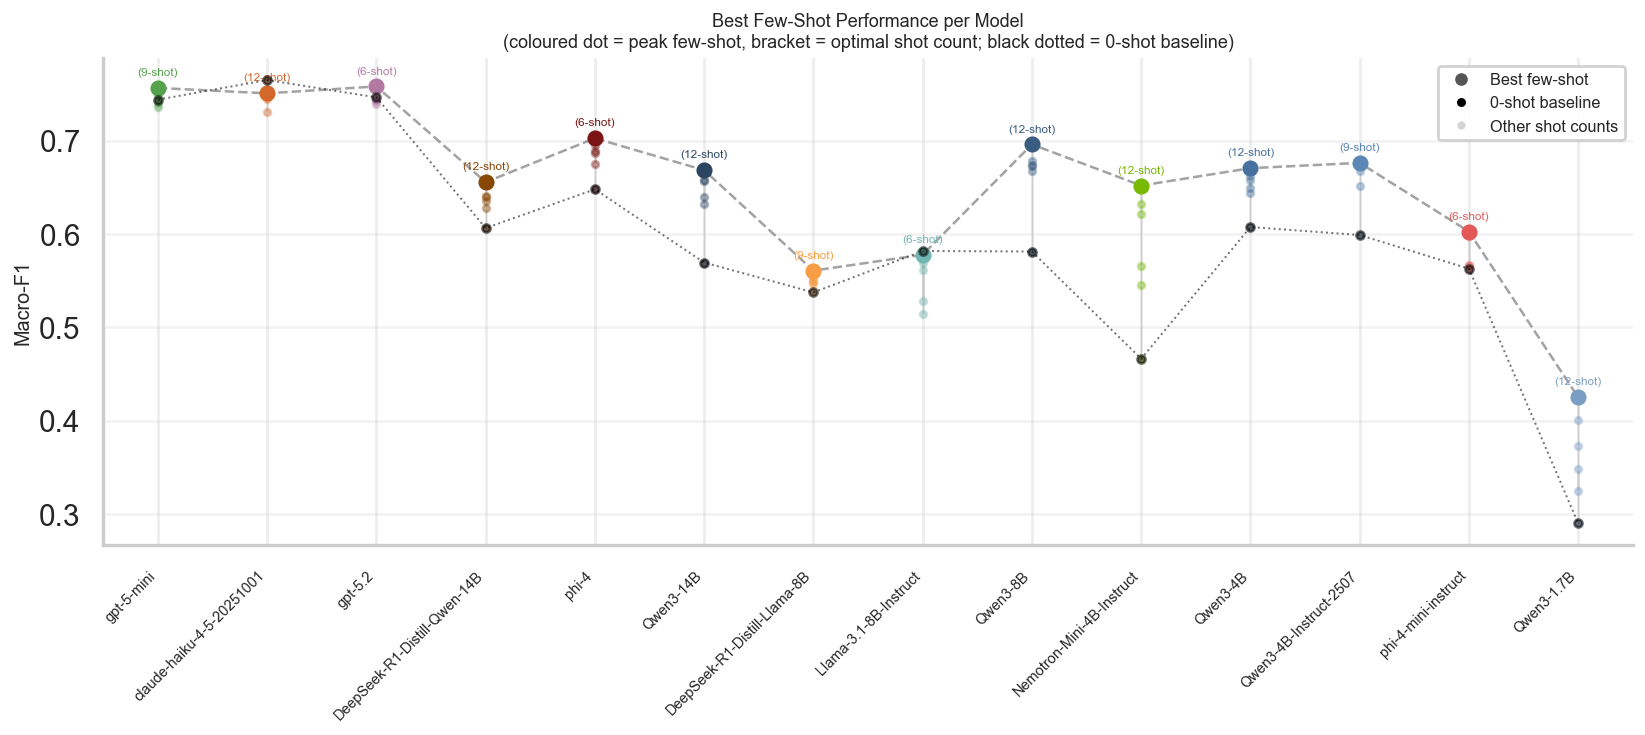

In [112]:
# ── Best few-shot vs all conditions: cross-model comparison ──────────────
from matplotlib.lines import Line2D

# Best few-shot condition per model (n_shots > 0 only)
fs_metrics = metrics[metrics['n_shots'] > 0]
best_idx   = fs_metrics.groupby('model')['macro_f1'].idxmax()
best_df    = fs_metrics.loc[best_idx].set_index('model')[['n_shots', 'macro_f1']]
best_df.columns = ['best_shots', 'best_f1']

# Sort models by best few-shot F1 descending
model_order_best = sorted(best_df.index, key=model_sort_key)
colors_best = build_model_colors(model_order_best)
x_pos = {m: i for i, m in enumerate(model_order_best)}

fig, ax = plt.subplots(figsize=(13, 6))

# Faint grey lines connecting all shot conditions per model
for model in model_order_best:
    sub = metrics[metrics['model'] == model].sort_values('n_shots')
    ax.plot([x_pos[model]] * len(sub), sub['macro_f1'],
            color='#cccccc', linewidth=0.8, zorder=1)

# Small dots for every shot condition
for _, row in metrics.iterrows():
    m = row['model']
    if m not in x_pos:
        continue
    ax.scatter(x_pos[m], row['macro_f1'],
               color=colors_best.get(m, '#aaa'), s=14, alpha=0.35, zorder=2)

# Dashed line connecting best few-shot peaks
bx = [x_pos[m] for m in model_order_best]
by = [best_df.loc[m, 'best_f1'] for m in model_order_best]
ax.plot(bx, by, color='#333', linewidth=1.4, linestyle='--', alpha=0.45, zorder=3)

# Coloured best-shot dots + bracket annotation
for model in model_order_best:
    x = x_pos[model]
    y = best_df.loc[model, 'best_f1']
    shots = int(best_df.loc[model, 'best_shots'])
    c = colors_best.get(model, '#555')
    ax.scatter(x, y, color=c, s=55, zorder=4)
    ax.annotate(f'({shots}-shot)', xy=(x, y), xytext=(0, 7),
                textcoords='offset points', ha='center', fontsize=6.5, color=c)

# 0-shot reference dots connected by a dotted line
z = metrics[metrics['n_shots'] == 0].copy()
z = z[z['model'].isin(x_pos)].sort_values('model', key=lambda s: s.map(x_pos))
ax.plot([x_pos[m] for m in z['model']], z['macro_f1'],
        color='black', linewidth=1.1, linestyle=':', alpha=0.55, zorder=3)
ax.scatter([x_pos[m] for m in z['model']], z['macro_f1'],
           color='black', s=20, alpha=0.5, zorder=4)

ax.set_xticks(range(len(model_order_best)))
ax.set_xticklabels(model_order_best, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title('Best Few-Shot Performance per Model\n'
             '(coloured dot = peak few-shot, bracket = optimal shot count; '
             'black dotted = 0-shot baseline)', fontsize=10)
ax.set_xlim(-0.5, len(model_order_best) - 0.5)
ax.grid(axis='y', alpha=0.25)

# Legend
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#555', markersize=8, label='Best few-shot'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='black', markersize=6,
           linestyle=':', label='0-shot baseline'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaa', markersize=5,
           alpha=0.5, label='Other shot counts'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9, framealpha=0.9)
plt.tight_layout()
plt.show()

Loaded 158 (model, prompt) combinations
Prompts: ['cot', 'default', 'default_no_label_definitions', 'few_shot', 'few_shot_12', 'few_shot_15', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'question', 'task_definition', 'task_definition_scale']


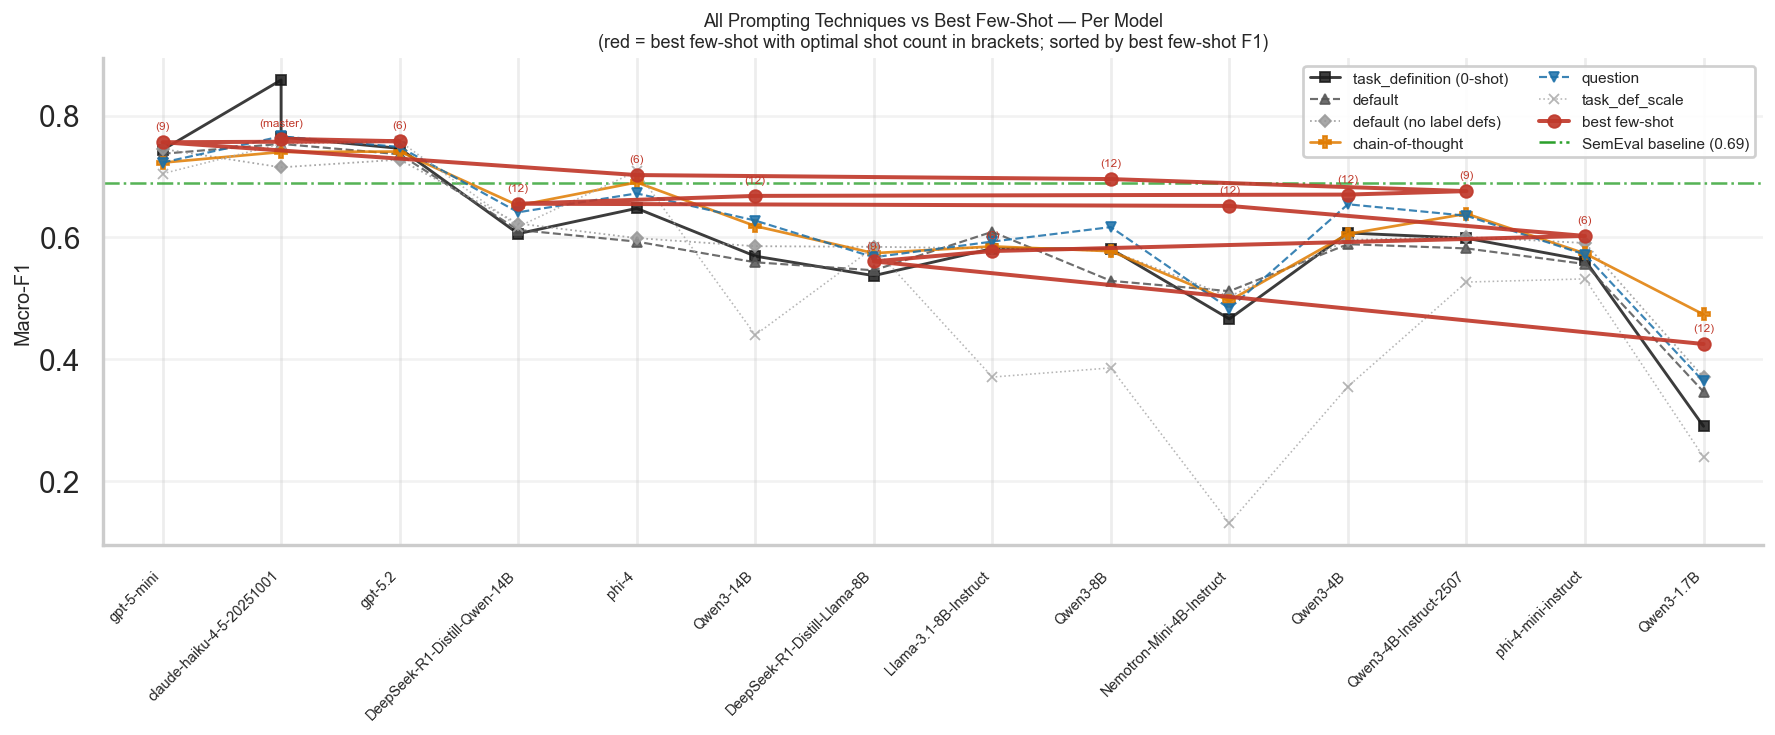

In [113]:
# ── All prompting techniques vs best few-shot (cross-method chart) ────────
from sklearn.metrics import f1_score

# Reload ALL run folders (no ICL filter)
_all_rows = []
for _run_dir in RUNS_ROOT.iterdir():
    _parsed = parse_run_folder(_run_dir.name)
    if _parsed is None:
        continue
    _model, _prompt = _parsed
    _csv = _run_dir / 'document_assignments.csv'
    if not _csv.exists():
        continue
    _df = pd.read_csv(_csv)
    if 'original_stance' not in _df.columns or 'predicted_stance' not in _df.columns:
        continue
    _df['_pred'] = _df['predicted_stance'].apply(norm_label)
    _df = _df.dropna(subset=['_pred'])
    if _df.empty:
        continue
    _yt = _df['original_stance'].values
    _yp = _df['_pred'].values
    _all_rows.append({
        'model':    _model,
        'prompt':   _prompt,
        'macro_f1': f1_score(_yt, _yp, labels=LABELS, average='macro', zero_division=0)
    })
all_metrics = pd.DataFrame(_all_rows)
print(f'Loaded {len(all_metrics)} (model, prompt) combinations')
print('Prompts:', sorted(all_metrics['prompt'].unique()))

# Identify few-shot vs other prompts
_FS_PROMPTS = {p for p in all_metrics['prompt'].unique() if p.startswith('few_shot')}
_OTHER_ORDER = ['task_definition', 'default', 'default_no_label_definitions',
                'cot', 'question', 'task_definition_scale']
_OTHER_ORDER = [p for p in _OTHER_ORDER if p in all_metrics['prompt'].unique()]

# Best few-shot per model
_fs = all_metrics[all_metrics['prompt'].isin(_FS_PROMPTS)]
_best_fs = (
    _fs.sort_values('macro_f1', ascending=False)
       .drop_duplicates('model')
       .set_index('model')[['prompt', 'macro_f1']]
)

# Sort models by best few-shot F1 descending
_models_sorted = _best_fs.sort_values('macro_f1', ascending=False).index.tolist()
_all_models = sorted(all_metrics['model'].unique(), key=model_sort_key)
_colors = build_model_colors(_all_models)
_x = {m: i for i, m in enumerate(_all_models)}

_STYLES = {
    'task_definition':              dict(color='#1a1a1a', lw=1.6, ls='-',  marker='s', ms=6),
    'default':                      dict(color='#555555', lw=1.2, ls='--', marker='^', ms=6),
    'default_no_label_definitions': dict(color='#999999', lw=1.0, ls=':',  marker='D', ms=5),
    'cot':                          dict(color='#e07b00', lw=1.5, ls='-',  marker='P', ms=7),
    'question':                     dict(color='#1a6fa8', lw=1.2, ls='--', marker='v', ms=6),
    'task_definition_scale':        dict(color='#aaaaaa', lw=0.9, ls=':',  marker='x', ms=5),
}
_LABELS_MAP = {
    'task_definition':              'task_definition (0-shot)',
    'default':                      'default',
    'default_no_label_definitions': 'default (no label defs)',
    'cot':                          'chain-of-thought',
    'question':                     'question',
    'task_definition_scale':        'task_def_scale',
}

fig, ax = plt.subplots(figsize=(14, 6))

# Non-few-shot prompt lines
for _p in _OTHER_ORDER:
    _st  = _STYLES[_p]
    _sub = (all_metrics[all_metrics['prompt'] == _p]
            .query('model in @_x')
            .sort_values('model', key=lambda s: s.map(_x)))
    if _sub.empty:
        continue
    ax.plot([_x[m] for m in _sub['model']], _sub['macro_f1'],
            color=_st['color'], linewidth=_st['lw'], linestyle=_st['ls'],
            marker=_st['marker'], markersize=_st['ms'],
            alpha=0.85, label=_LABELS_MAP[_p], zorder=3)

# Best few-shot line (red, thick)
_bx = [_x[m] for m in _models_sorted if m in _x]
_by = [_best_fs.loc[m, 'macro_f1'] for m in _models_sorted if m in _x]
ax.plot(_bx, _by, color='#c0392b', linewidth=2.2, linestyle='-',
        marker='o', markersize=7, alpha=0.92, label='best few-shot', zorder=4)

# Annotate with optimal shot count in brackets
for _m in _models_sorted:
    if _m not in _x or _m not in _best_fs.index:
        continue
    _tag = _best_fs.loc[_m, 'prompt'].replace('few_shot_', '').replace('few_shot', 'master')
    ax.annotate(f'({_tag})', xy=(_x[_m], _best_fs.loc[_m, 'macro_f1']),
                xytext=(0, 7), textcoords='offset points',
                ha='center', fontsize=6.5, color='#c0392b')

ax.set_xticks(range(len(_all_models)))
ax.set_xticklabels(_all_models, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title(
    'All Prompting Techniques vs Best Few-Shot — Per Model\n'
    '(red = best few-shot with optimal shot count in brackets; sorted by best few-shot F1)',
    fontsize=10)
ax.set_xlim(-0.5, len(_all_models) - 0.5)
ax.grid(axis='y', alpha=0.25)
ax.axhline(SEMEVAL_BASELINE, color='#2ca02c', linewidth=1.4,
           linestyle='-.', alpha=0.8, zorder=2)

from matplotlib.lines import Line2D as _L2D
_baseline_handle = _L2D([0],[0], color='#2ca02c', linewidth=1.4,
                        linestyle='-.', label=f'SemEval baseline ({SEMEVAL_BASELINE})')
_handles, _lbls = ax.get_legend_handles_labels()
ax.legend(handles=_handles + [_baseline_handle], labels=_lbls + [f'SemEval baseline ({SEMEVAL_BASELINE})'],
          loc='upper right', fontsize=8.5, framealpha=0.92, ncol=2)
plt.tight_layout()
plt.show()

---
## 9 · Carbon & GPU Efficiency

**RQ9:** How do carbon consumption and GPU memory utilisation vary across prompting methods and model sizes?

Only vLLM-served (non-GPT) models are included — GPT models have no local carbon tracking.  
Results are drawn from `semeval_results/` which combines:
- **Few-shot runs** (3 / 6 / 9 / 12 / 15 shots) from the new `_shot` batch.
- **All other methods** (default, cot, task_definition, etc.) from the original results folder.

In [114]:
# ── Carbon & GPU data loading from semeval_results ──────────
import json as _json
import re as _re2
from pathlib import Path
from sklearn.metrics import f1_score as _f1_score

SEMEVAL_ROOT = Path('../data_out/stance/semeval_results')

# Extend model metadata for new models not in MODEL_SIZES
_EXTRA_SIZES  = {'Ministral-3-3B-Instruct-2512': 3.0}
_EXTRA_FAMILY = {'Ministral-3-3B-Instruct-2512': 'Ministral'}
_EXTRA_FAM_COLORS = {'Ministral': '#9467bd'}

def _msize(m):   return MODEL_SIZES.get(m, _EXTRA_SIZES.get(m))
def _mfamily(m): return MODEL_FAMILY.get(m, _EXTRA_FAMILY.get(m, 'Other'))
def _msort(m):
    _cs = _CLOSED_SOURCE_RANK.get(m, 99) if _msize(m) is None else 99
    return (-((_msize(m) or 999)), _cs, _mfamily(m), m)

def _ct_sort_key(path):
    # Sort carbontracker logs by ISO timestamp embedded in filename,
    # not by job-ID prefix (which is unordered). This ensures we always
    # pick the most recent (completed) run when multiple attempts exist.
    m = _re2.search(r'(\d{4}-\d{2}-\d{2}T\d{6}Z)', path.name)
    return m.group(1) if m else path.name

def _parse_ct_output(log_path):
    co2, energy, in_actual = None, None, False
    try:
        for line in log_path.read_text(errors='replace').split('\n'):
            if 'Actual consumption' in line: in_actual = True
            if in_actual:
                m = _re2.search(r'Energy:\s*([\d.]+)\s*kWh', line)
                if m: energy = float(m.group(1))
                m = _re2.search(r'CO2eq:\s*([\d.]+)\s*g', line)
                if m: co2 = float(m.group(1))
    except Exception: pass
    return co2, energy

def _parse_ct_power(log_path):
    try:
        for line in log_path.read_text(errors='replace').split('\n'):
            if 'Average power usage' in line:
                m = _re2.search(r':\s*([\d.]+)\s*$', line.strip())
                if m: return float(m.group(1))
    except Exception: pass
    return None

carbon_rows = []
for _rd in sorted(SEMEVAL_ROOT.iterdir()):
    if not _rd.is_dir(): continue
    _parsed = parse_run_folder(_rd.name)
    if _parsed is None: continue
    _model, _prompt = _parsed
    if _model.lower().startswith('gpt'): continue

    _gpu_util = _gpu_mem_mb = None
    _sj = _rd / 'summary.json'
    if _sj.exists():
        try:
            _s = _json.load(open(_sj))
            _gs = (_s.get('runs') or [{}])[0].get('gpu_stats') or {}
            _gpu_util   = _gs.get('memory_utilization_percent')
            _gpu_mem_mb = _gs.get('memory_used_mb')
        except Exception: pass

    _ct = _rd / 'carbontracker'
    _co2 = _energy = _power = None
    if _ct.exists():
        _out_logs  = sorted(_ct.glob('*_carbontracker_output.log'), key=_ct_sort_key)
        _main_logs = sorted(_ct.glob('*_carbontracker.log'),        key=_ct_sort_key)
        if _out_logs:  _co2, _energy = _parse_ct_output(_out_logs[-1])
        if _main_logs: _power = _parse_ct_power(_main_logs[-1])

    _macro_f1 = None
    _csv = _rd / 'document_assignments.csv'
    if _csv.exists():
        try:
            _df = pd.read_csv(_csv)
            if {'original_stance', 'predicted_stance'} <= set(_df.columns):
                _yt = _df['original_stance'].values
                _yp = _df['predicted_stance'].apply(norm_label).values
                _mask = pd.Series(_yp).isin(LABELS) & pd.Series(_yt).isin(LABELS)
                if _mask.sum() > 0:
                    _macro_f1 = _f1_score(_yt[_mask], _yp[_mask],
                                          labels=LABELS, average='macro', zero_division=0)
        except Exception: pass

    carbon_rows.append(dict(
        model=_model, prompt=_prompt,
        co2_g=_co2, energy_kwh=_energy, power_w=_power,
        gpu_util_pct=_gpu_util, gpu_mem_mb=_gpu_mem_mb,
        macro_f1=_macro_f1,
    ))

carbon_df = pd.DataFrame(carbon_rows)
print(f'Entries total:   {len(carbon_df)}')
print(f'With CO2 data:   {carbon_df["co2_g"].notna().sum()}')
print(f'With GPU util:   {carbon_df["gpu_util_pct"].notna().sum()}')
print(f'With macro-F1:   {carbon_df["macro_f1"].notna().sum()}')
print(f'Models:  {sorted(carbon_df["model"].unique(), key=_msort)}')
print(f'Prompts: {sorted(carbon_df["prompt"].unique())}')

# Shared style constants (reused across the charts below)
_FS_SHOTS = sorted(
    [p for p in carbon_df['prompt'].unique() if p.startswith('few_shot_')],
    key=lambda p: int(p.split('_')[-1])
)
_NFS_PROMPTS = [p for p in
    ['task_definition', 'default', 'default_no_label_definitions',
     'cot', 'question', 'task_definition_scale']
    if p in carbon_df['prompt'].unique()
]
_NFS_STYLES = {
    'task_definition':              dict(color='#1a1a1a', lw=1.6, ls='-',  marker='s', ms=6),
    'default':                      dict(color='#555555', lw=1.2, ls='--', marker='^', ms=6),
    'default_no_label_definitions': dict(color='#999999', lw=1.0, ls=':',  marker='D', ms=5),
    'cot':                          dict(color='#e07b00', lw=1.5, ls='-',  marker='P', ms=7),
    'question':                     dict(color='#1a6fa8', lw=1.2, ls='--', marker='v', ms=6),
    'task_definition_scale':        dict(color='#aaaaaa', lw=0.9, ls=':',  marker='x', ms=5),
}
_NFS_LABELS = {
    'task_definition':              'task_definition (0-shot)',
    'default':                      'default',
    'default_no_label_definitions': 'default (no label defs)',
    'cot':                          'chain-of-thought',
    'question':                     'question',
    'task_definition_scale':        'task_def_scale',
}
import matplotlib.cm as _mcm
_n_fs = len(_FS_SHOTS)
_blues = [_mcm.Blues(0.35 + 0.55 * i / max(_n_fs - 1, 1)) for i in range(_n_fs)]

carbon_df.groupby('prompt')[['co2_g', 'gpu_util_pct']].agg(['mean', 'min', 'max']).round(3)

Entries total:   157
With CO2 data:   121
With GPU util:   120
With macro-F1:   134
Models:  ['claude-haiku-4-5-20251001', 'DeepSeek-R1-Distill-Qwen-32B', 'Qwen3-32B', 'DeepSeek-R1-Distill-Qwen-14B', 'phi-4', 'Qwen3-14B', 'DeepSeek-R1-Distill-Llama-8B', 'Llama-3.1-8B-Instruct', 'Qwen3-8B', 'Nemotron-Mini-4B-Instruct', 'Qwen3-4B', 'Qwen3-4B-Instruct-2507', 'phi-4-mini-instruct', 'Ministral-3-3B-Instruct-2512', 'Qwen3-1.7B']
Prompts: ['cot', 'default', 'default_no_label_definitions', 'few_shot', 'few_shot_12', 'few_shot_15', 'few_shot_3', 'few_shot_6', 'few_shot_9', 'question', 'task_definition', 'task_definition_scale']


co2_g             gpu_util_pct              
                              mean   min   max         mean    min    max
prompt                                                                   
cot                          3.374 0.436 7.422       70.663 62.100 72.770
default                      3.338 0.870 7.161       70.419 62.090 72.590
default_no_label_definitions 2.735 0.207 6.315       70.755 62.090 72.770
few_shot                       NaN   NaN   NaN          NaN    NaN    NaN
few_shot_12                  1.443 0.195 4.208       61.651 61.130 62.350
few_shot_15                  1.515 0.241 4.375       61.651 61.130 62.350
few_shot_3                   1.998 0.325 5.305       61.651 61.130 62.350
few_shot_6                   1.426 0.194 4.010       61.652 61.130 62.350
few_shot_9                   1.392 0.198 4.191       61.650 61.130 62.350
question                     1.863 0.223 4.757       70.457 62.090 72.870
task_definition              1.871 0.221 4.320       70.443 62.090 72.770
task_definition_scale        3.452 0.240 9.069       61.650 61.130 62.350

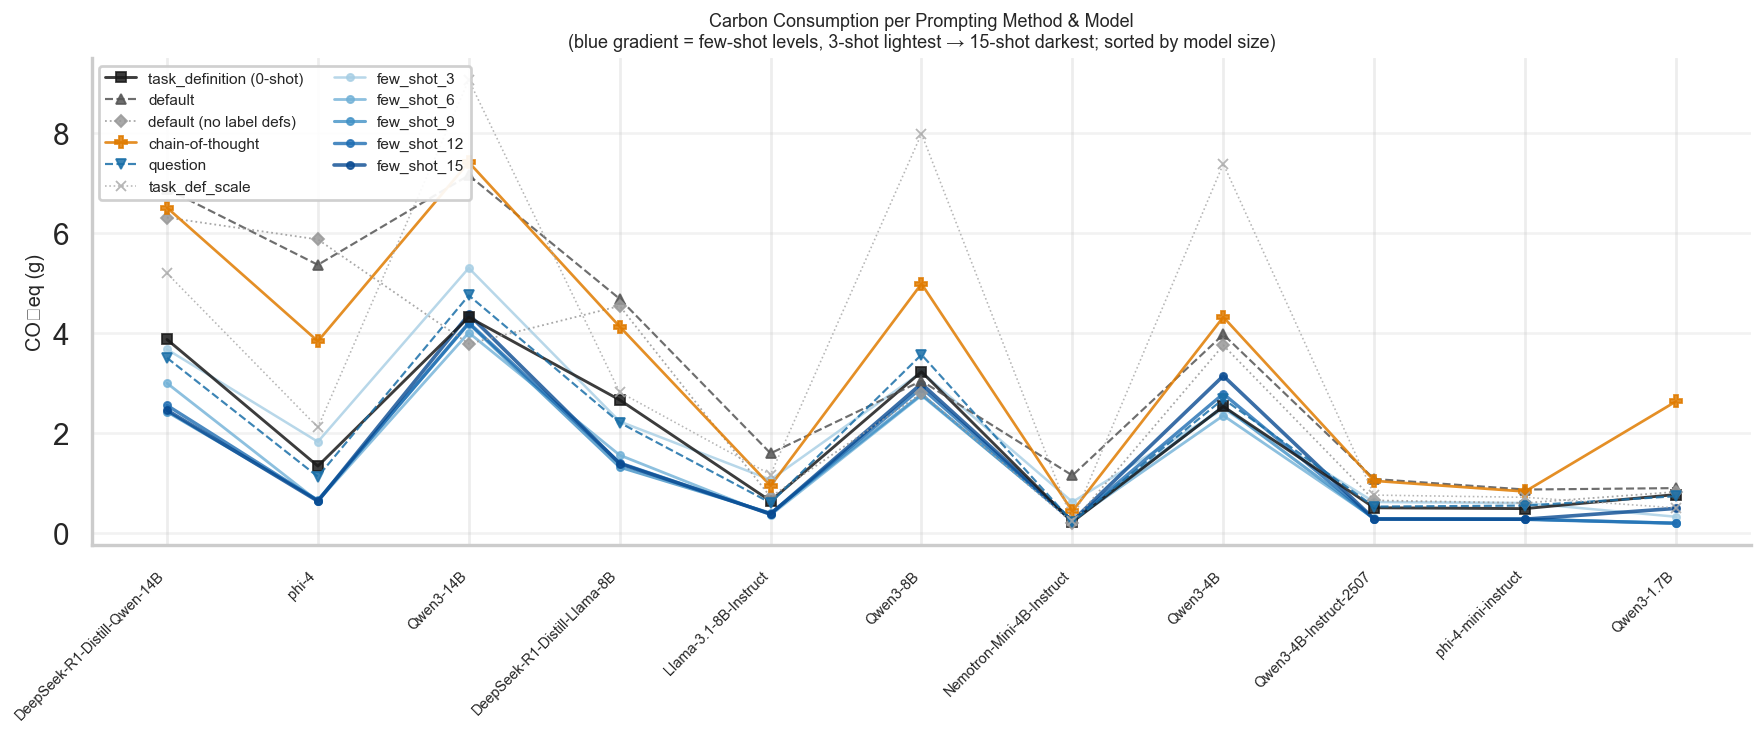

In [115]:
# ── CO2 consumption by prompting method & model ────────────
# Structure mirrors the 'All Prompting Techniques' chart (cell 42).
# x = models sorted by parameter count; lines = prompting method.
# Blue gradient: 3-shot (lightest) → 15-shot (darkest).

_co2 = carbon_df.dropna(subset=['co2_g']).copy()
_co2_models = sorted(_co2['model'].unique(), key=_msort)
_xc = {m: i for i, m in enumerate(_co2_models)}

fig, ax = plt.subplots(figsize=(14, 6))

for _p in _NFS_PROMPTS:
    _st  = _NFS_STYLES[_p]
    _sub = _co2[_co2['prompt'] == _p].copy()
    _sub = _sub[_sub['model'].isin(_xc)].sort_values('model', key=lambda s: s.map(_xc))
    if _sub.empty: continue
    ax.plot([_xc[m] for m in _sub['model']], _sub['co2_g'],
            color=_st['color'], lw=_st['lw'], ls=_st['ls'],
            marker=_st['marker'], ms=_st['ms'],
            alpha=0.85, label=_NFS_LABELS[_p], zorder=3)

for _i, _p in enumerate(_FS_SHOTS):
    _n = _p.split('_')[-1]
    _sub = _co2[_co2['prompt'] == _p].copy()
    _sub = _sub[_sub['model'].isin(_xc)].sort_values('model', key=lambda s: s.map(_xc))
    if _sub.empty: continue
    ax.plot([_xc[m] for m in _sub['model']], _sub['co2_g'],
            color=_blues[_i], lw=1.4 + 0.15 * _i, ls='-',
            marker='o', ms=4, alpha=0.80,
            label=f'few_shot_{_n}', zorder=2)

ax.set_xticks(range(len(_co2_models)))
ax.set_xticklabels(_co2_models, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('CO\u2082eq (g)', fontsize=11)
ax.set_title(
    'Carbon Consumption per Prompting Method & Model\n'
    '(blue gradient = few-shot levels, 3-shot lightest \u2192 15-shot darkest; '
    'sorted by model size)',
    fontsize=10)
ax.set_xlim(-0.5, len(_co2_models) - 0.5)
ax.grid(axis='y', alpha=0.25)
_h, _l = ax.get_legend_handles_labels()
ax.legend(handles=_h, labels=_l, loc='upper left', fontsize=8.5,
          framealpha=0.92, ncol=2)
plt.tight_layout()
plt.show()


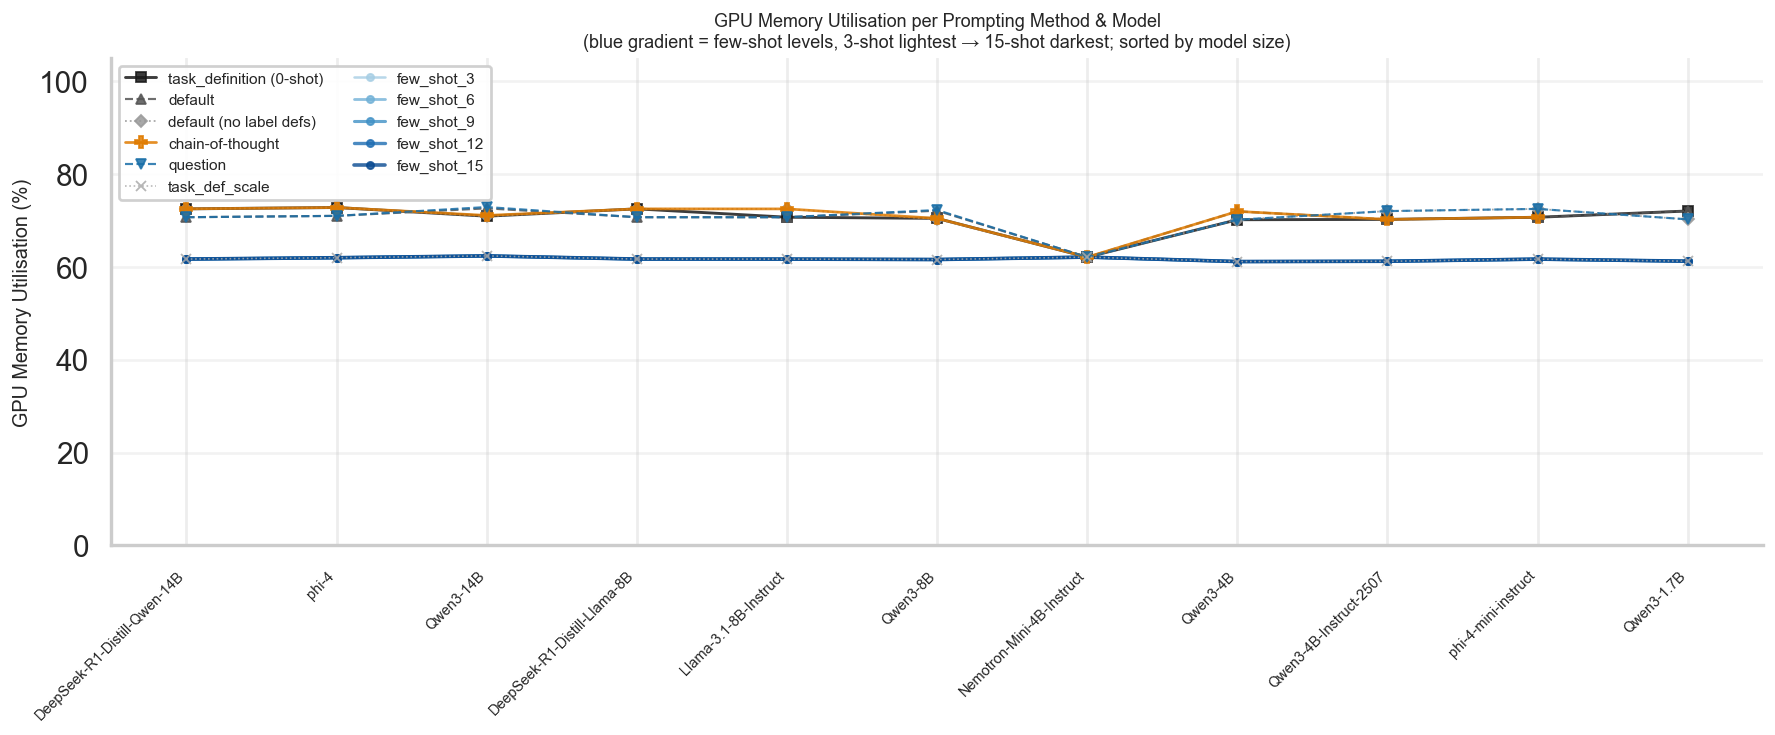

In [116]:
# ── GPU memory utilisation by prompting method & model ────────
# GPU memory utilisation = (model weights + KV-cache) / total GPU memory.
# Larger models dominate; few-shot adds modest KV-cache overhead.

_gpu = carbon_df.dropna(subset=['gpu_util_pct']).copy()
_gpu_models = sorted(_gpu['model'].unique(), key=_msort)
_xg = {m: i for i, m in enumerate(_gpu_models)}

fig, ax = plt.subplots(figsize=(14, 6))

for _p in _NFS_PROMPTS:
    _st  = _NFS_STYLES[_p]
    _sub = _gpu[_gpu['prompt'] == _p].copy()
    _sub = _sub[_sub['model'].isin(_xg)].sort_values('model', key=lambda s: s.map(_xg))
    if _sub.empty: continue
    ax.plot([_xg[m] for m in _sub['model']], _sub['gpu_util_pct'],
            color=_st['color'], lw=_st['lw'], ls=_st['ls'],
            marker=_st['marker'], ms=_st['ms'],
            alpha=0.85, label=_NFS_LABELS.get(_p, _p), zorder=3)

for _i, _p in enumerate(_FS_SHOTS):
    _n = _p.split('_')[-1]
    _sub = _gpu[_gpu['prompt'] == _p].copy()
    _sub = _sub[_sub['model'].isin(_xg)].sort_values('model', key=lambda s: s.map(_xg))
    if _sub.empty: continue
    ax.plot([_xg[m] for m in _sub['model']], _sub['gpu_util_pct'],
            color=_blues[_i], lw=1.4 + 0.15 * _i, ls='-',
            marker='o', ms=4, alpha=0.80,
            label=f'few_shot_{_n}', zorder=2)

ax.set_xticks(range(len(_gpu_models)))
ax.set_xticklabels(_gpu_models, rotation=45, ha='right', fontsize=8)
ax.set_ylabel('GPU Memory Utilisation (%)', fontsize=11)
ax.set_title(
    'GPU Memory Utilisation per Prompting Method & Model\n'
    '(blue gradient = few-shot levels, 3-shot lightest \u2192 15-shot darkest; '
    'sorted by model size)',
    fontsize=10)
ax.set_xlim(-0.5, len(_gpu_models) - 0.5)
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.25)
_h, _l = ax.get_legend_handles_labels()
ax.legend(handles=_h, labels=_l, loc='upper left', fontsize=8.5,
          framealpha=0.92, ncol=2)
plt.tight_layout()
plt.show()


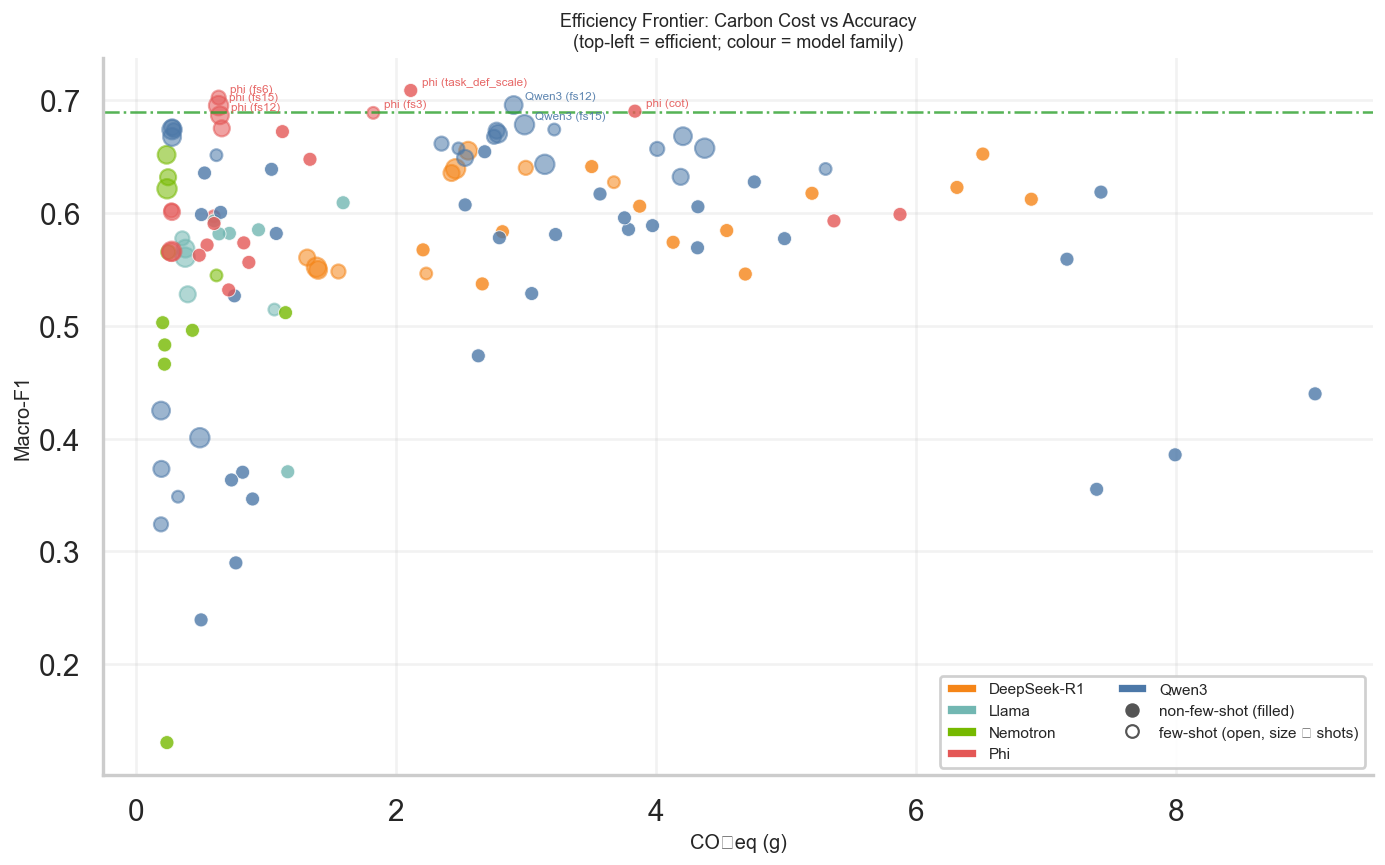

In [117]:
# ── Efficiency frontier: CO2 vs macro-F1 per (model, method) ───────
# Each dot = one (model, prompting-method) combination.
# Top-left corner = efficient: high accuracy, low carbon cost.

_eff = carbon_df.dropna(subset=['co2_g', 'macro_f1']).copy()
_eff['family'] = _eff['model'].map(lambda m: MODEL_FAMILY.get(m, _EXTRA_FAMILY.get(m, 'Other')))
_eff['fcolor'] = _eff['family'].map(
    lambda f: {**FAMILY_COLORS, **_EXTRA_FAM_COLORS}.get(f, '#888888'))
_eff['is_fs']  = _eff['prompt'].str.startswith('few_shot')
_eff['shot_n'] = _eff['prompt'].apply(
    lambda p: int(p.split('_')[-1]) if p.startswith('few_shot_') and p.split('_')[-1].isdigit() else 0)

fig, ax = plt.subplots(figsize=(11, 7))

_nfs_eff = _eff[~_eff['is_fs']]
ax.scatter(_nfs_eff['co2_g'], _nfs_eff['macro_f1'],
           c=_nfs_eff['fcolor'], s=60, alpha=0.80,
           edgecolors='white', lw=0.5, zorder=3, label='non-few-shot')

_fs_eff = _eff[_eff['is_fs']]
ax.scatter(_fs_eff['co2_g'], _fs_eff['macro_f1'],
           c=_fs_eff['fcolor'], s=25 + 6 * _fs_eff['shot_n'],
           alpha=0.55, edgecolors=_fs_eff['fcolor'],
           linewidths=1.2, facecolors='none', zorder=2, label='few-shot')

# Annotate top-6 highest F1 points
_annotated = set()
for _, row in _eff.sort_values('macro_f1', ascending=False).head(8).iterrows():
    _key = (row['model'], row['prompt'])
    if _key in _annotated: continue
    _annotated.add(_key)
    _tag = row['prompt'].replace('few_shot_', 'fs').replace('task_definition', 'task_def')
    ax.annotate(f"{row['model'].split('-')[0]} ({_tag})",
                xy=(row['co2_g'], row['macro_f1']),
                xytext=(6, 3), textcoords='offset points',
                fontsize=6.5, color=row['fcolor'], alpha=0.9)

ax.axhline(SEMEVAL_BASELINE, color='#2ca02c', lw=1.4, ls='-.',
           alpha=0.8, label=f'SemEval baseline ({SEMEVAL_BASELINE})')

from matplotlib.patches import Patch as _Patch
_fam_handles = [
    _Patch(facecolor={**FAMILY_COLORS, **_EXTRA_FAM_COLORS}.get(f, '#888'), label=f)
    for f in sorted(_eff['family'].unique())
]
_extra_handles = [
    Line2D([0],[0], marker='o', color='#555', markersize=7, lw=0,
           label='non-few-shot (filled)'),
    Line2D([0],[0], marker='o', color='#555', markersize=7, lw=0,
           markerfacecolor='none', markeredgewidth=1.2,
           label='few-shot (open, size \u221d shots)'),
]
ax.legend(handles=_fam_handles + _extra_handles,
          loc='lower right', fontsize=8.5, framealpha=0.92, ncol=2)

ax.set_xlabel('CO\u2082eq (g)', fontsize=11)
ax.set_ylabel('Macro-F1', fontsize=11)
ax.set_title(
    'Efficiency Frontier: Carbon Cost vs Accuracy\n'
    '(top-left = efficient; colour = model family)',
    fontsize=10)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()
